# 18 — 4mu ABCD two-dimensional isolation scan

Focused first look at the 4mu ABCD closure across the two isolation thresholds.

- One-axis scans cover 0.50 to 1.00 while holding the other isolation cut at the nominal 0.25.
- Two-dimensional scans cover 0.05 to 1.00.
- Background MC closure is evaluated in the SR and inverted-displacement VR.
- Data closure is evaluated only in the inverted-displacement VR; Data SR A is never accessed.
- The scan spans 0.05 to 1.00.
- Statistical uncertainties use histogram `sumw2` and first-order propagation, as in notebook 15. Low-effective-statistics MC points require caution.

In [1]:
import gc
import sys
from pathlib import Path

search_roots = [Path.cwd(), *Path.cwd().parents]
SIDM_DIR = next((path for path in search_roots if path.name == "sidm"), None)
assert SIDM_DIR is not None, "Could not locate the sidm repository root"
if str(SIDM_DIR.parent) not in sys.path:
    sys.path.insert(1, str(SIDM_DIR.parent))

import coffea.util
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

if int(np.__version__.split(".")[0]) < 2:
    import numpy.core as _numpy_core
    import numpy.core.numeric as _numpy_numeric
    sys.modules.setdefault("numpy._core", _numpy_core)
    sys.modules.setdefault("numpy._core.numeric", _numpy_numeric)

%matplotlib inline

## 1. Inputs and scan definition

In [2]:
STUDY_DIR = SIDM_DIR / "studies/ABCD_Study"
BKG_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_bkg_merged_samples_v1"
DATA_INPUT_DIR = STUDY_DIR / "ABCD_golden_hotspot_iso025_v1_data_merged_samples_v1"
HIST_NAME = "mulj_mulj_iso"
TOPOLOGY = "4mu"
X_LABEL = "Leading Mu-LJ Isolation"
Y_LABEL = "Subleading Mu-LJ Isolation"
BACKGROUND_ORDER = ["QCD", "DY", "TTJets", "Diboson"]
SCAN_VALUES = np.array([
    0.05, 0.10, 0.15, 0.20, 0.25,
    0.30, 0.40, 0.50, 0.60, 0.75, 1.00,
])
ONE_D_SCAN_VALUES = np.round(np.arange(0.50, 1.001, 0.05), 2)
NOMINAL_CUTS = (0.25, 0.25)

CHANNELS = {
    "SR": "test_SR_4mu_spread_cosAlpha_mu_veto",
    "VR-invDisplaced": "test_VR_4mu_invDisplaced_spread_cosAlpha_mu_veto",
}
TARGETS = (
    ("SR", "BKG total", "MC SR"),
    ("VR-invDisplaced", "BKG total", "MC VR"),
    ("VR-invDisplaced", "Data", "Data VR"),
)

assert np.all((SCAN_VALUES >= 0.05) & (SCAN_VALUES <= 1.0))
assert np.all(np.diff(SCAN_VALUES) > 0)
assert np.all((ONE_D_SCAN_VALUES >= 0.50) & (ONE_D_SCAN_VALUES <= 1.0))
assert not any(selection == "SR" and group == "Data"
               for selection, group, _ in TARGETS)

def classify_sample(sample):
    if sample.startswith("DoubleMuon"): return "Data"
    if sample.startswith("QCD_"): return "QCD"
    if sample.startswith("DYJetsTo"): return "DY"
    if sample.startswith("TTJets"): return "TTJets"
    if sample in {"WW", "WZ", "ZZ"}: return "Diboson"
    return "Other"

background_paths = sorted(BKG_INPUT_DIR.glob("*.coffea"))
data_paths = sorted(DATA_INPUT_DIR.glob("DoubleMuon*.coffea"))
assert background_paths and data_paths
print(f"Background files: {len(background_paths)}; Data files: {len(data_paths)}")
print(f"2D grid: {len(SCAN_VALUES)} x {len(SCAN_VALUES)} = {len(SCAN_VALUES)**2} points")

Background files: 18; Data files: 68
2D grid: 11 x 11 = 121 points


In [3]:
outputs = {}
for path in [*background_paths, *data_paths]:
    sample = path.stem
    try:
        loaded = coffea.util.load(path)
        payload = loaded.get("out", loaded)[sample]
        outputs[sample] = payload["hists"][HIST_NAME]
    except Exception as error:
        print(f"**** Failed to load {sample}: {error}")
        outputs.pop(sample, None)
    finally:
        loaded = payload = None
        gc.collect()

sample_groups = {}
for sample in outputs:
    sample_groups.setdefault(classify_sample(sample), []).append(sample)
sample_groups["BKG total"] = sum(
    (sample_groups.get(group, []) for group in BACKGROUND_ORDER), []
)

for sample, hist in outputs.items():
    available = set(hist.axes["channel"])
    missing = set(CHANNELS.values()) - available
    assert not missing, f"{sample}/{HIST_NAME} missing channels: {sorted(missing)}"

print({group: len(samples) for group, samples in sample_groups.items()})

{'DY': 2, 'QCD': 12, 'TTJets': 1, 'Diboson': 3, 'Data': 68, 'BKG total': 18}


## 2. ABCD and statistical helpers

In [4]:
def sample_hist(sample, selection):
    return outputs[sample][{"channel": CHANNELS[selection]}]

def group_hist(group, selection):
    members = [group] if group in outputs else sample_groups.get(group, [])
    hists = [sample_hist(sample, selection) for sample in members]
    if not hists:
        return None
    total = hists[0].copy()
    for hist in hists[1:]:
        total = total + hist
    return total

def values_variances(h2d):
    # Fold overflow into the last visible isolation-fail bin; exclude underflow.
    values = np.asarray(h2d.values(flow=True), dtype=float).copy()
    variances = h2d.variances(flow=True)
    variances = (np.clip(values, 0, None) if variances is None
                 else np.asarray(variances, dtype=float).copy())
    values[-2, :] += values[-1, :]
    variances[-2, :] += variances[-1, :]
    values, variances = values[:-1, :], variances[:-1, :]
    values[:, -2] += values[:, -1]
    variances[:, -2] += variances[:, -1]
    values, variances = values[:, :-1], variances[:, :-1]
    return values[1:, 1:], variances[1:, 1:]

def abcd_masks(h2d, xcut, ycut):
    x = np.asarray(h2d.axes[0].centers)[:, None]
    y = np.asarray(h2d.axes[1].centers)[None, :]
    return {
        "A": (x < xcut) & (y < ycut),
        "B": (x >= xcut) & (y < ycut),
        "C": (x < xcut) & (y >= ycut),
        "D": (x >= xcut) & (y >= ycut),
    }

def region_stats(h2d, cuts):
    values, variances = values_variances(h2d)
    result = {}
    for region, mask in abcd_masks(h2d, *cuts).items():
        value = float(values[mask].sum())
        variance = float(np.clip(variances[mask].sum(), 0, None))
        result[region] = {
            "yield": value,
            "error": np.sqrt(variance),
            "neff": value**2 / variance if variance > 0 else np.nan,
        }
    return result

def prediction(stats):
    b, c, d = (stats[region]["yield"] for region in "BCD")
    eb, ec, ed = (stats[region]["error"] for region in "BCD")
    if b <= 0 or c <= 0 or d <= 0:
        return np.nan, np.nan
    pred = b * c / d
    relative_variance = (eb / b)**2 + (ec / c)**2 + (ed / d)**2
    return pred, abs(pred) * np.sqrt(relative_variance)

def closure_row(h2d, cuts):
    stats = region_stats(h2d, cuts)
    pred, pred_err = prediction(stats)
    obs, obs_err = stats["A"]["yield"], stats["A"]["error"]
    ratio = obs / pred if pred > 0 else np.nan
    ratio_err = (abs(ratio) * np.sqrt((obs_err / obs)**2 + (pred_err / pred)**2)
                 if obs > 0 and pred > 0 else np.nan)
    denominator = np.sqrt(obs_err**2 + pred_err**2)
    row = {
        "xcut": cuts[0], "ycut": cuts[1],
        "A_pred": pred, "A_pred_err": pred_err,
        "observed_over_predicted": ratio,
        "observed_over_predicted_err": ratio_err,
        "pull": (obs - pred) / denominator if denominator > 0 else np.nan,
    }
    for region in "ABCD":
        for field in ("yield", "error", "neff"):
            row[f"{region}_{field}"] = stats[region][field]
    finite_neff = [stats[r]["neff"] for r in "ABCD" if np.isfinite(stats[r]["neff"])]
    row["min_neff"] = min(finite_neff) if finite_neff else np.nan
    row["relative_pred_err"] = pred_err / pred if pred > 0 else np.nan
    return row

## 3. Leading/subleading Mu-LJ isolation correlations

The joint-style plots show the binned two-dimensional yield and both marginal distributions. The weighted Pearson coefficient measures linear correlation within the displayed $0 < \mathrm{isolation} < 1$ range; a value near zero does not by itself prove independence. ABCD closure remains the direct factorization test.

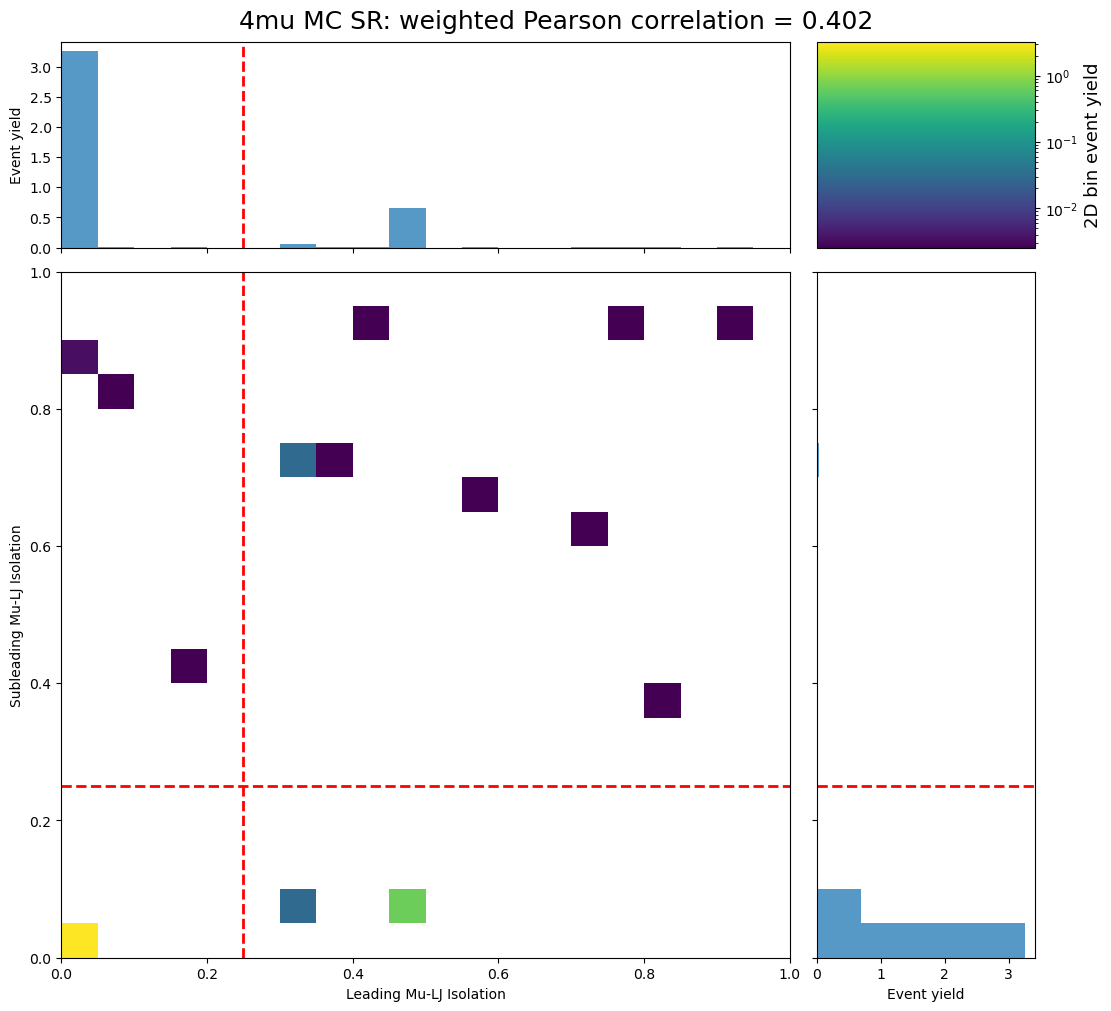

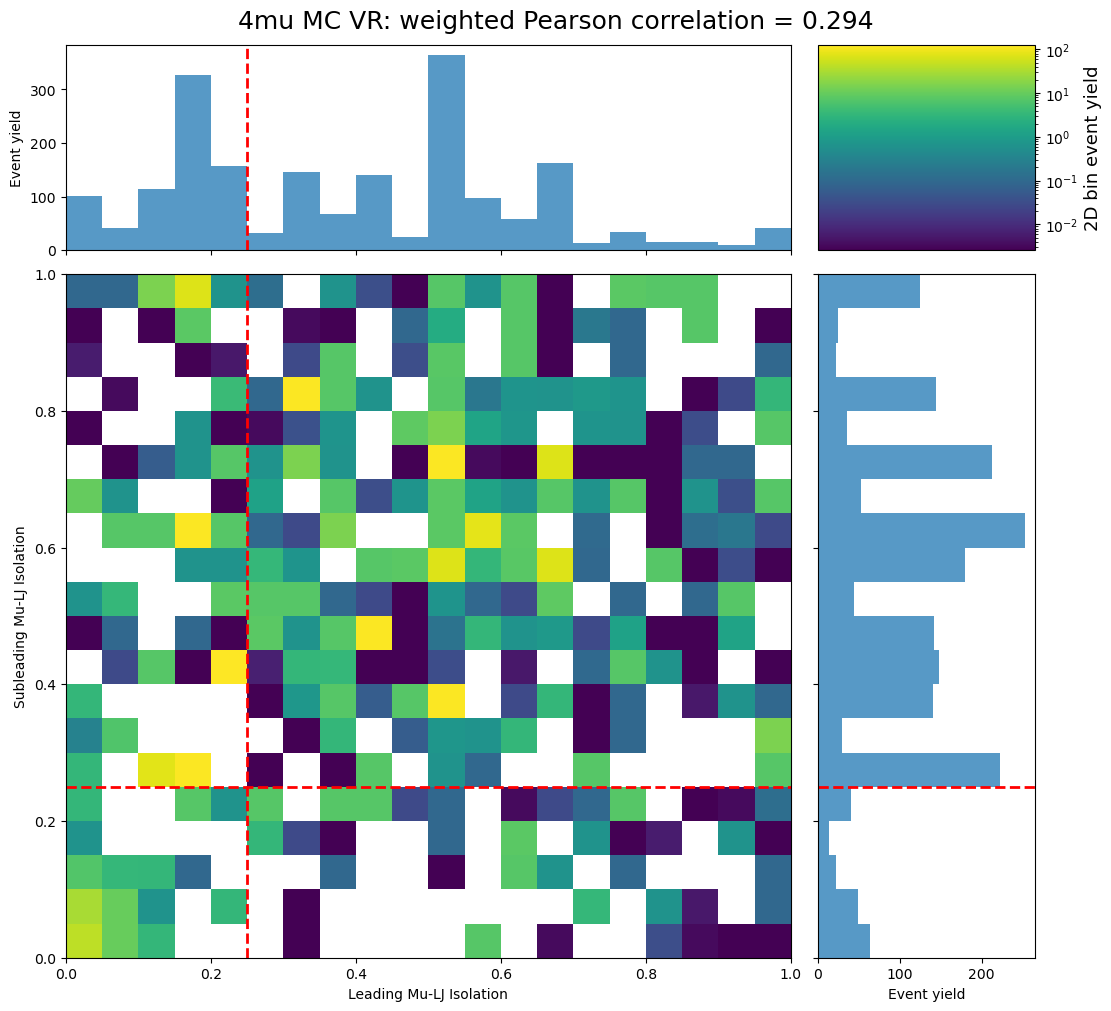

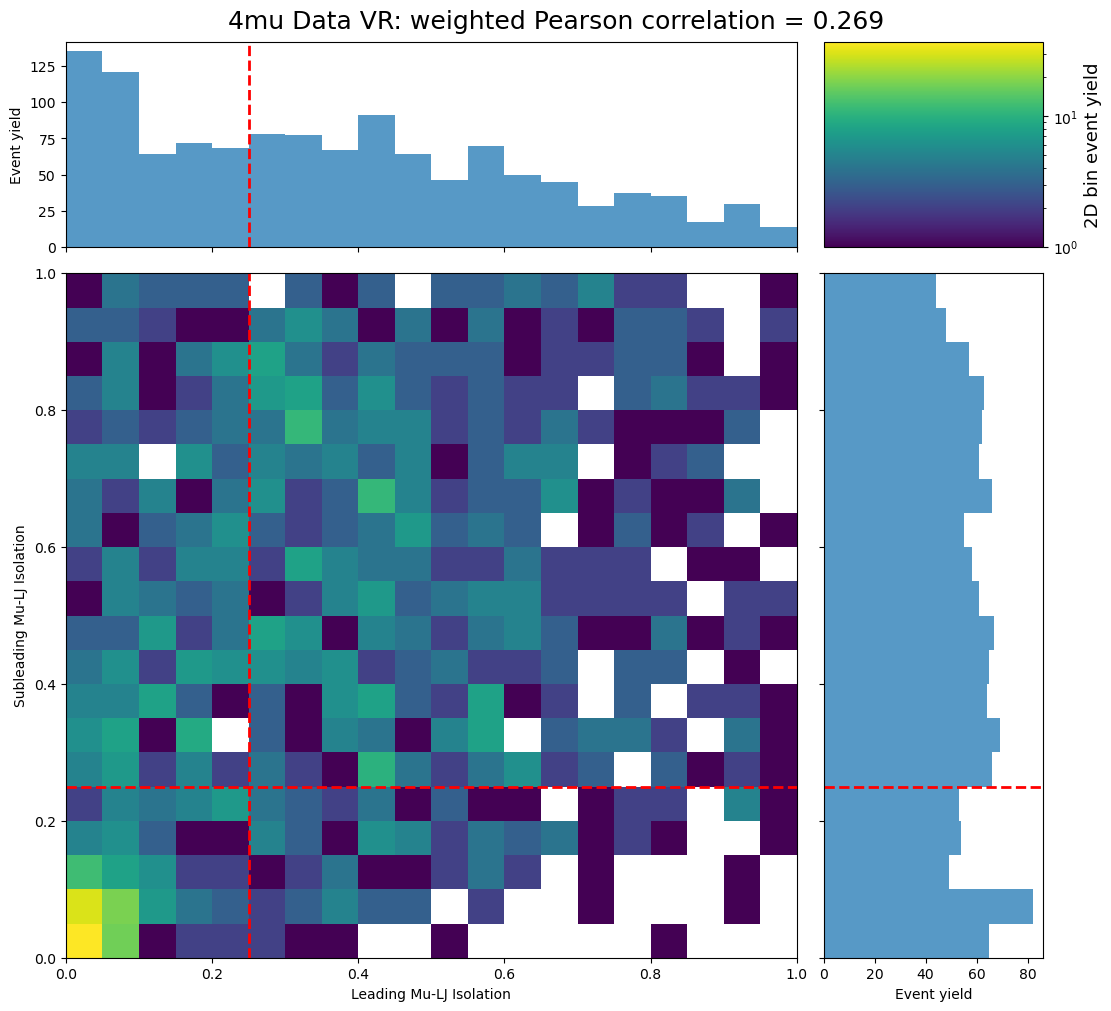

,target,weighted_pearson,negative_bins,total_yield_0to1
0,MC SR,0.402182,0,3.994206
1,MC VR,0.293782,0,1967.904218
2,Data VR,0.269467,0,1209.000000


In [5]:
def correlation_inputs(hist, maximum=1.0):
    values, _ = values_variances(hist)
    xedges = np.asarray(hist.axes[0].edges)
    yedges = np.asarray(hist.axes[1].edges)
    xcenters = np.asarray(hist.axes[0].centers)
    ycenters = np.asarray(hist.axes[1].centers)
    xmask = (xcenters >= 0) & (xcenters <= maximum)
    ymask = (ycenters >= 0) & (ycenters <= maximum)
    return (values[np.ix_(xmask, ymask)], xcenters[xmask], ycenters[ymask],
            xedges[np.r_[np.flatnonzero(xmask), np.flatnonzero(xmask)[-1] + 1]],
            yedges[np.r_[np.flatnonzero(ymask), np.flatnonzero(ymask)[-1] + 1]])

def weighted_pearson(values, xcenters, ycenters):
    total = values.sum()
    if total <= 0:
        return np.nan
    xgrid, ygrid = np.meshgrid(xcenters, ycenters, indexing="ij")
    mean_x = np.sum(values * xgrid) / total
    mean_y = np.sum(values * ygrid) / total
    variance_x = np.sum(values * (xgrid - mean_x)**2) / total
    variance_y = np.sum(values * (ygrid - mean_y)**2) / total
    covariance = np.sum(values * (xgrid - mean_x) * (ygrid - mean_y)) / total
    denominator = np.sqrt(variance_x * variance_y)
    return covariance / denominator if denominator > 0 else np.nan

def plot_binned_joint(hist, label):
    values, xcenters, ycenters, xedges, yedges = correlation_inputs(hist)
    negative_bins = int(np.count_nonzero(values < 0))
    rho = weighted_pearson(values, xcenters, ycenters)
    positive_values = values[values > 0]
    assert positive_values.size, f"No positive event yield for {label}"

    fig = plt.figure(figsize=(11, 10), constrained_layout=True)
    grid = fig.add_gridspec(2, 2, width_ratios=(4, 1.2), height_ratios=(1.2, 4))
    ax_top = fig.add_subplot(grid[0, 0])
    ax_main = fig.add_subplot(grid[1, 0], sharex=ax_top)
    ax_right = fig.add_subplot(grid[1, 1], sharey=ax_main)
    ax_color = fig.add_subplot(grid[0, 1])

    image = ax_main.pcolormesh(
        xedges, yedges, np.ma.masked_less_equal(values.T, 0),
        shading="auto", cmap="viridis",
        norm=LogNorm(vmin=positive_values.min(), vmax=positive_values.max()),
    )
    ax_top.stairs(values.sum(axis=1), xedges, fill=True, alpha=0.75)
    ax_right.stairs(values.sum(axis=0), yedges, orientation="horizontal",
                    fill=True, alpha=0.75)
    ax_main.axvline(0.25, color="red", linestyle="--", linewidth=2)
    ax_main.axhline(0.25, color="red", linestyle="--", linewidth=2)
    ax_top.axvline(0.25, color="red", linestyle="--", linewidth=2)
    ax_right.axhline(0.25, color="red", linestyle="--", linewidth=2)
    ax_main.set(xlim=(0, 1), ylim=(0, 1), xlabel=X_LABEL, ylabel=Y_LABEL)
    ax_top.set(ylabel="Event yield")
    ax_right.set(xlabel="Event yield")
    ax_top.tick_params(axis="x", labelbottom=False)
    ax_right.tick_params(axis="y", labelleft=False)
    colorbar = fig.colorbar(image, cax=ax_color)
    colorbar.set_label("2D bin event yield", fontsize=13)
    fig.suptitle(
        f"4mu {label}: weighted Pearson correlation = {rho:.3f}",
        fontsize=18,
    )
    return fig, {"target": label, "weighted_pearson": rho,
                 "negative_bins": negative_bins, "total_yield_0to1": values.sum()}

correlation_rows = []
for selection, group, label in TARGETS:
    fig, row = plot_binned_joint(group_hist(group, selection), label)
    correlation_rows.append(row)
    plt.show(); plt.close(fig)
correlation_summary = pd.DataFrame(correlation_rows)
display(correlation_summary)

## 4. Conditional-mean correlation profiles

These companion plots expose trends that a single Pearson coefficient can miss. They show the conditional weighted mean of each isolation variable as a function of the other, plus the corresponding two-variable Pearson matrix.

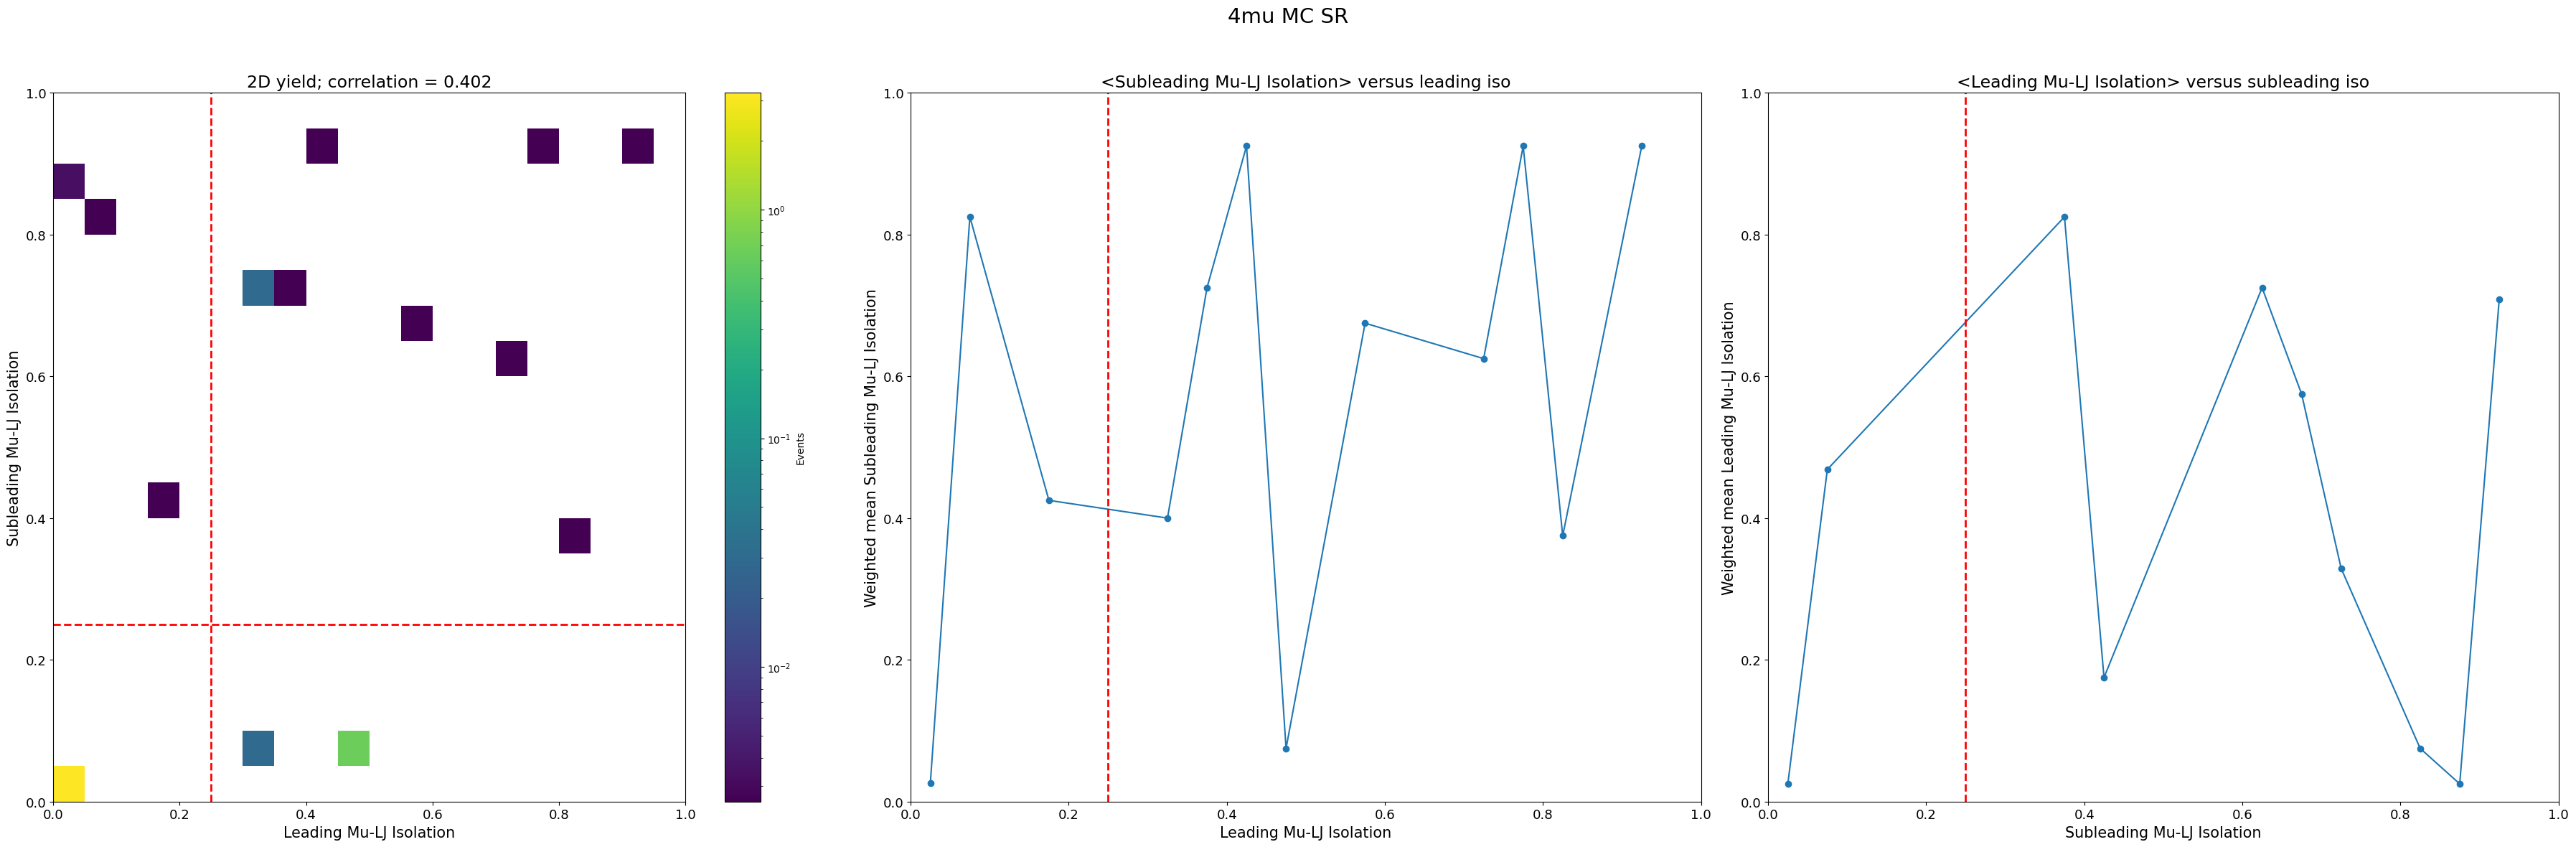

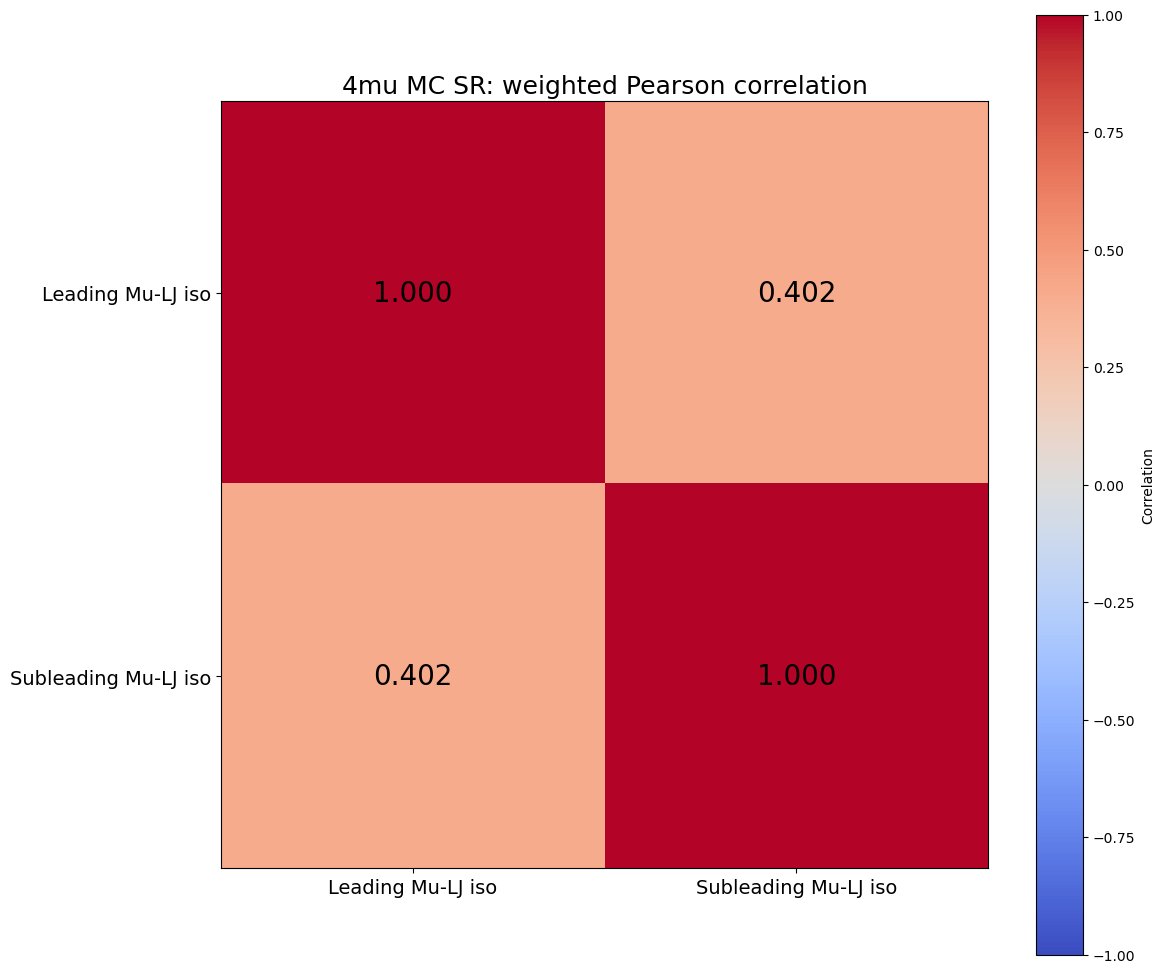

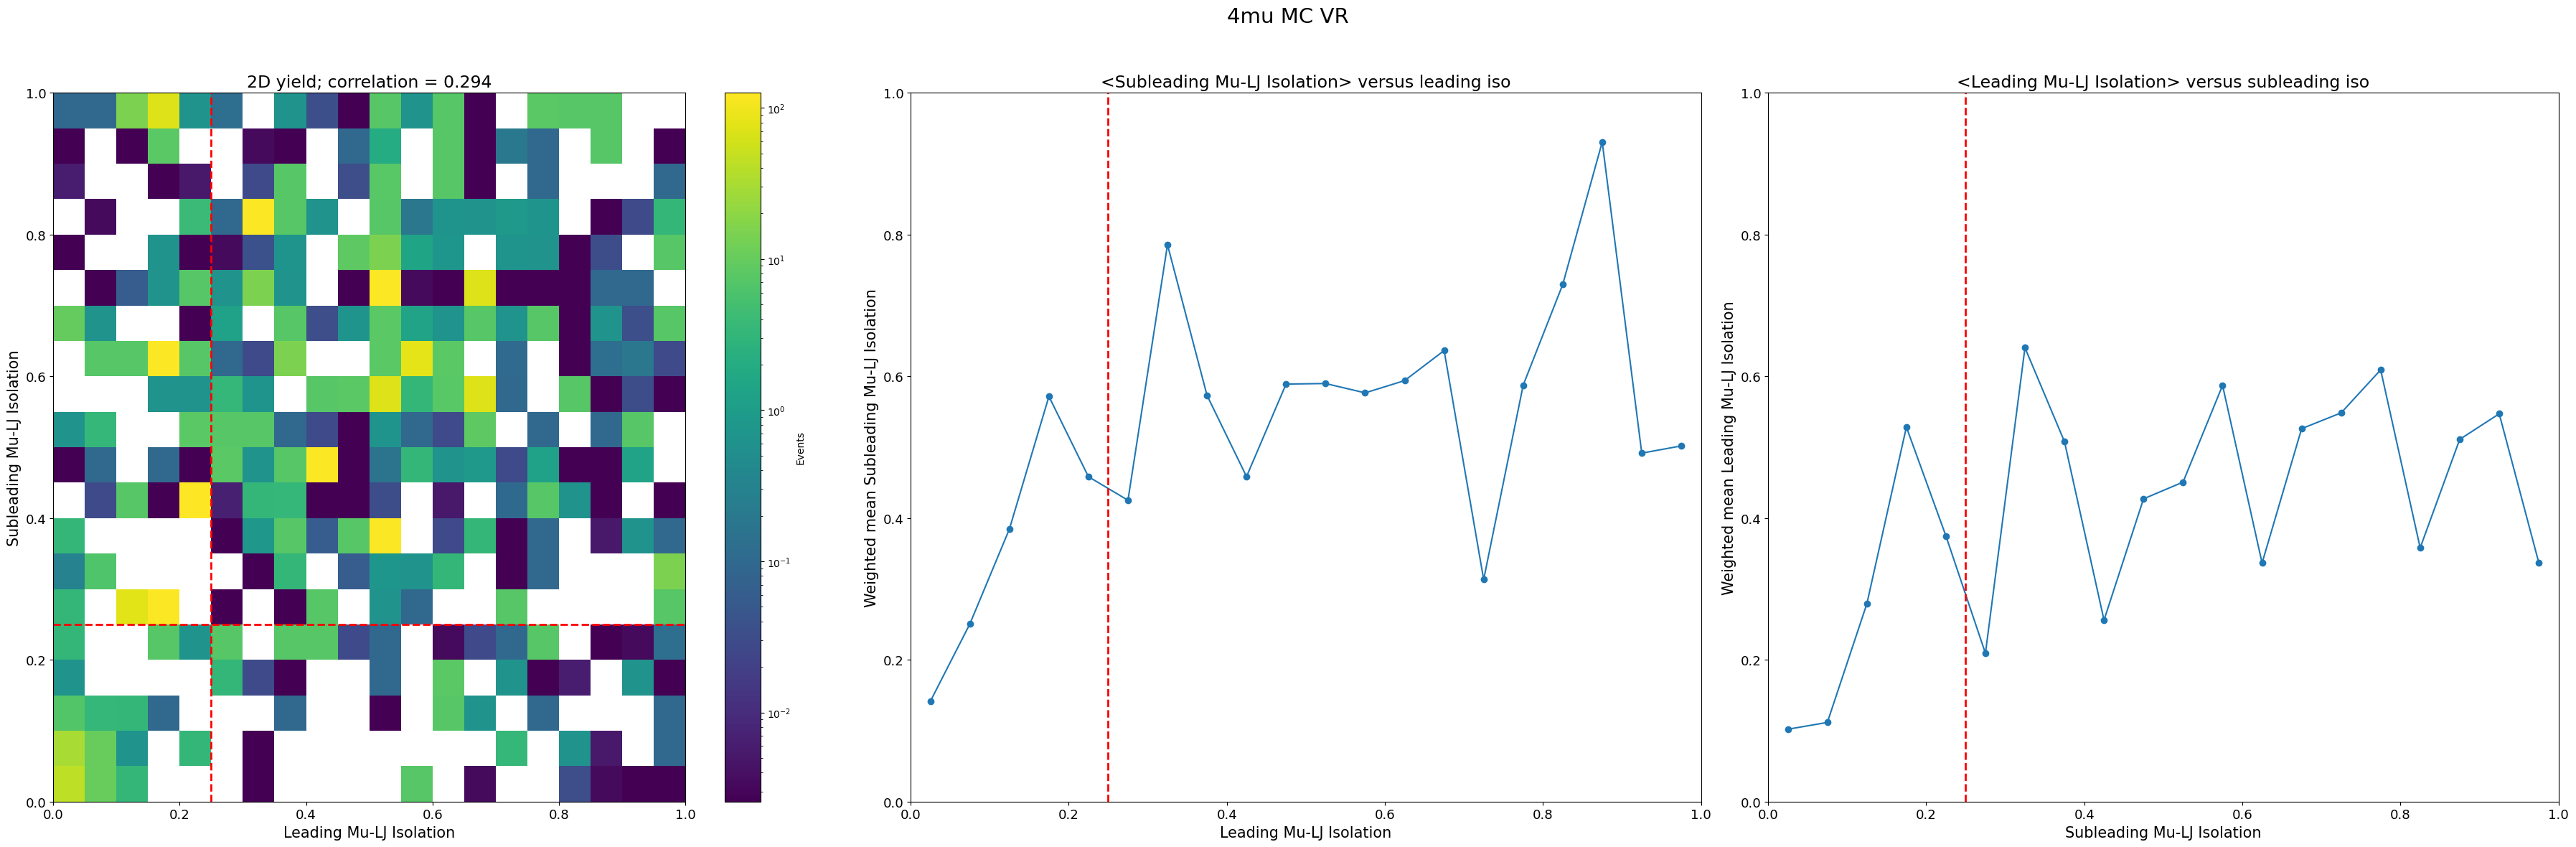

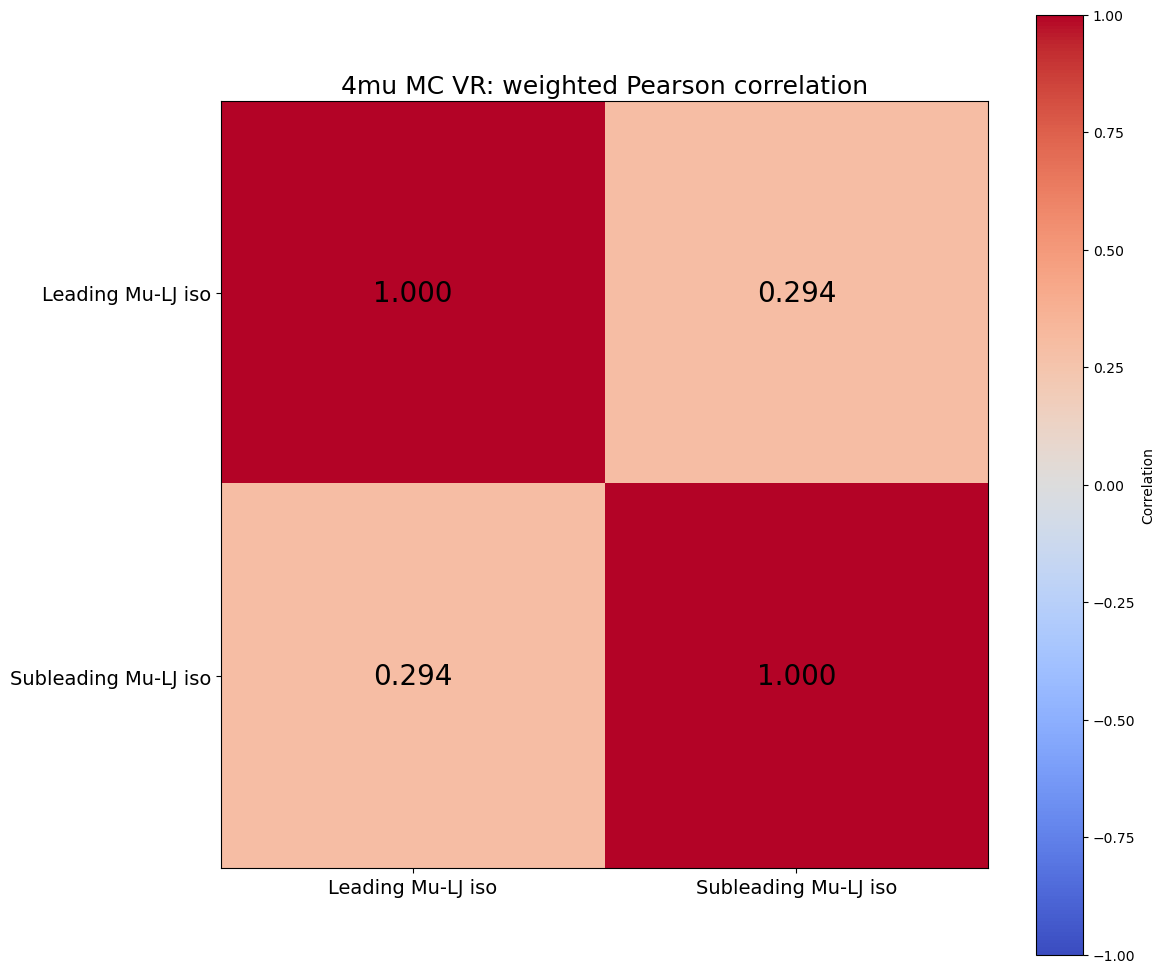

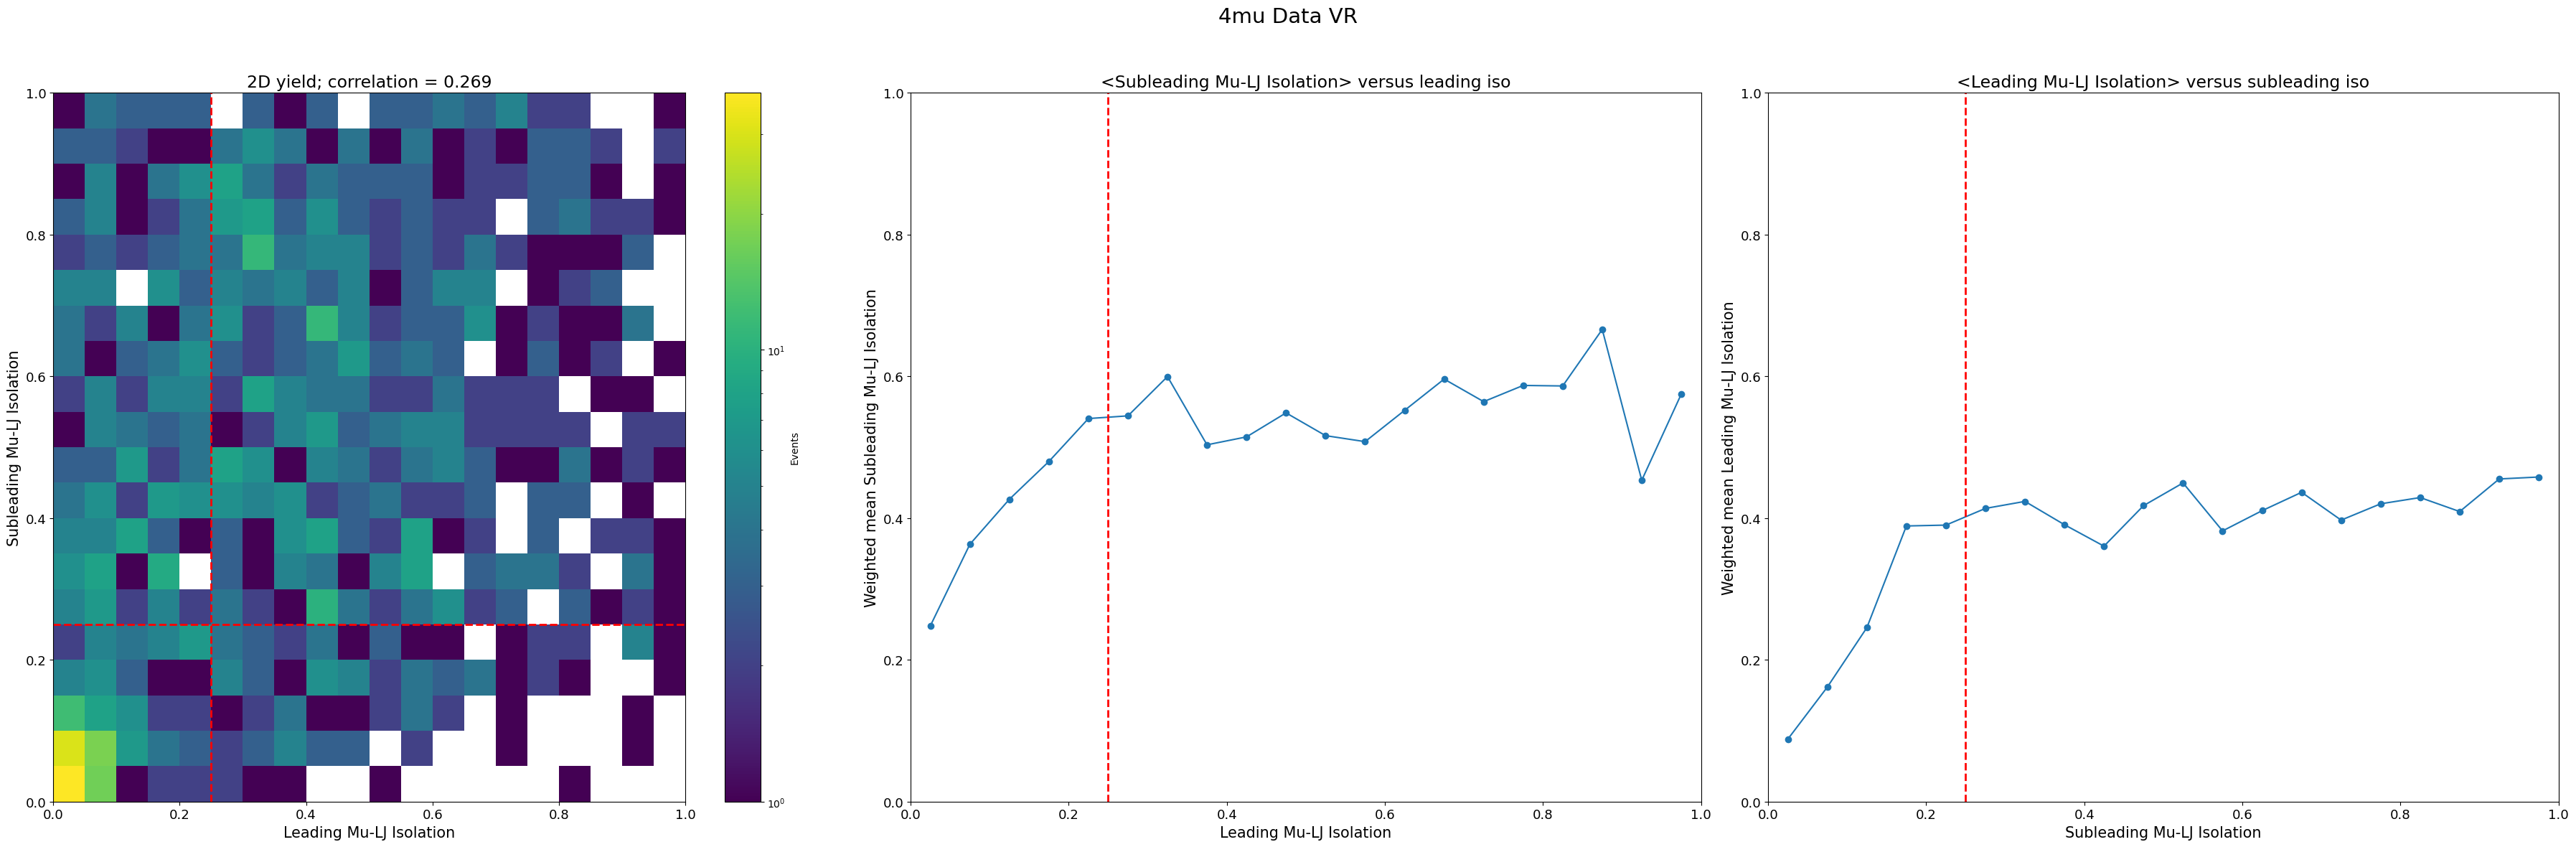

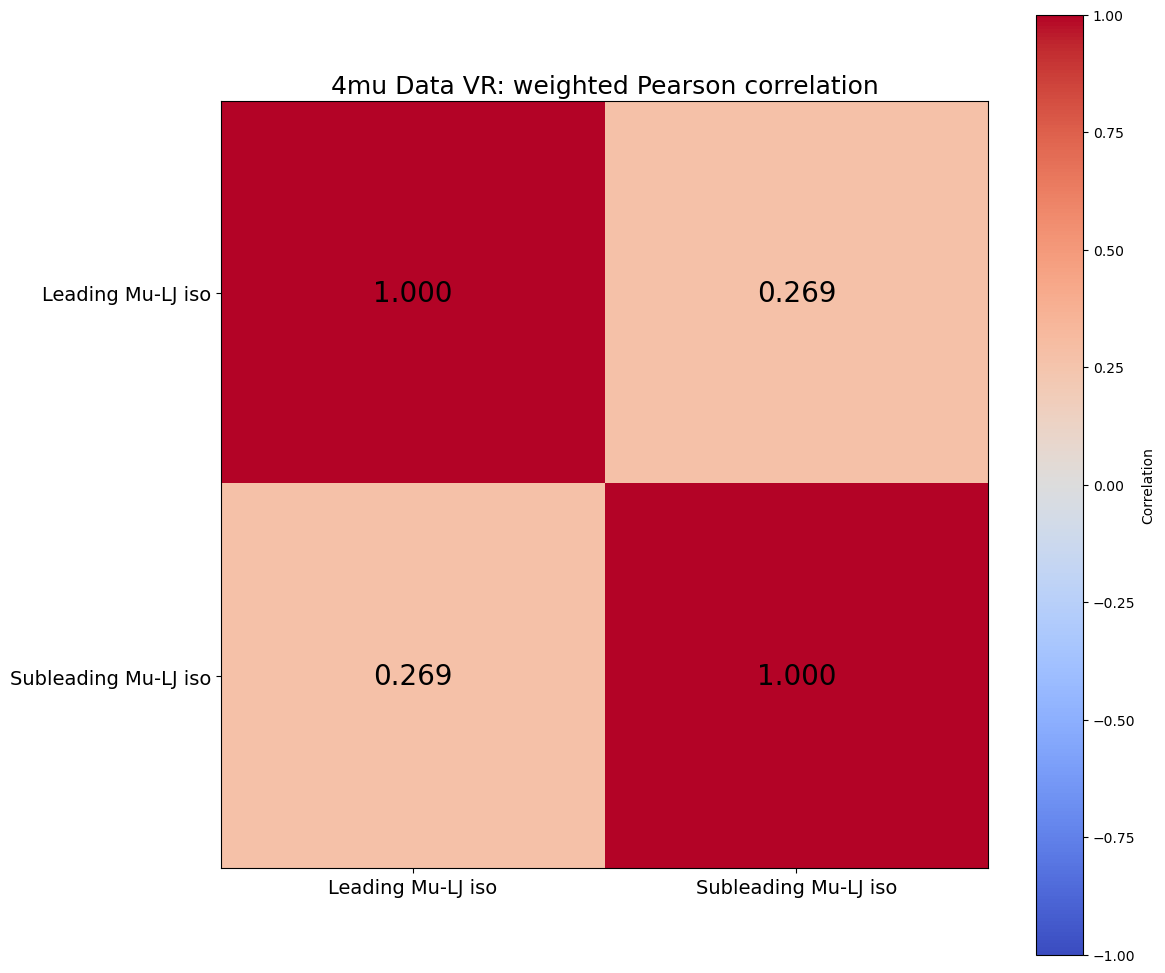

In [6]:
def hist2d_to_dataframe(h2d):
    values, xcenters, ycenters, xedges, yedges = correlation_inputs(h2d)
    xgrid, ygrid = np.meshgrid(xcenters, ycenters, indexing="ij")
    frame = pd.DataFrame({
        "leading_iso": xgrid.ravel(),
        "subleading_iso": ygrid.ravel(),
        "yield": values.ravel(),
    })
    return frame, values, xcenters, ycenters, xedges, yedges

def weighted_corr(h2d):
    values, xcenters, ycenters, _, _ = correlation_inputs(h2d)
    return weighted_pearson(values, xcenters, ycenters)

def plot_correlation_profile(h2d, title):
    frame, values, _, _, xedges, yedges = hist2d_to_dataframe(h2d)
    positive = frame[np.isfinite(frame["yield"]) & (frame["yield"] > 0)].copy()
    corr = weighted_corr(h2d)
    plotted_values = values.T
    positive_values = plotted_values[np.isfinite(plotted_values) & (plotted_values > 0)]
    norm = None
    if positive_values.size:
        vmin = max(positive_values.min(), 1e-12)
        vmax = max(positive_values.max(), vmin * (1 + 1e-12))
        norm = LogNorm(vmin=vmin, vmax=vmax)

    fig, axes = plt.subplots(1, 3, figsize=(36, 12))
    mesh = axes[0].pcolormesh(
        xedges, yedges, np.ma.masked_less_equal(plotted_values, 0),
        shading="auto", cmap="viridis", norm=norm,
    )
    fig.colorbar(mesh, ax=axes[0], label="Events")
    axes[0].axvline(0.25, color="red", linestyle="--", linewidth=2)
    axes[0].axhline(0.25, color="red", linestyle="--", linewidth=2)
    axes[0].set(
        xlim=(0, 1), ylim=(0, 1),
        title=f"2D yield; correlation = {corr:.3f}",
        xlabel=X_LABEL, ylabel=Y_LABEL,
    )

    if not positive.empty:
        subleading_profile = pd.Series({
            value: np.average(group["subleading_iso"], weights=group["yield"])
            for value, group in positive.groupby("leading_iso")
        })
        leading_profile = pd.Series({
            value: np.average(group["leading_iso"], weights=group["yield"])
            for value, group in positive.groupby("subleading_iso")
        })
        axes[1].plot(subleading_profile.index, subleading_profile.values, marker="o")
        axes[2].plot(leading_profile.index, leading_profile.values, marker="o")
    axes[1].axvline(0.25, color="red", linestyle="--", linewidth=2)
    axes[2].axvline(0.25, color="red", linestyle="--", linewidth=2)
    axes[1].set(
        xlim=(0, 1), ylim=(0, 1), xlabel=X_LABEL,
        ylabel=f"Weighted mean {Y_LABEL}", title=f"<{Y_LABEL}> versus leading iso",
    )
    axes[2].set(
        xlim=(0, 1), ylim=(0, 1), xlabel=Y_LABEL,
        ylabel=f"Weighted mean {X_LABEL}", title=f"<{X_LABEL}> versus subleading iso",
    )
    for ax in axes:
        ax.tick_params(axis="both", labelsize=13)
        ax.xaxis.label.set_size(15); ax.yaxis.label.set_size(15); ax.title.set_size(17)
    fig.suptitle(title, fontsize=21)
    fig.tight_layout(rect=(0, 0, 1, 0.95))

    matrix_fig, matrix_ax = plt.subplots(figsize=(12, 10))
    matrix = np.array([[1.0, corr], [corr, 1.0]])
    image = matrix_ax.imshow(matrix, vmin=-1, vmax=1, cmap="coolwarm")
    for row in range(2):
        for column in range(2):
            matrix_ax.text(column, row, f"{matrix[row, column]:.3f}",
                           ha="center", va="center", fontsize=20)
    short_labels = ["Leading Mu-LJ iso", "Subleading Mu-LJ iso"]
    matrix_ax.set(
        xticks=[0, 1], yticks=[0, 1],
        xticklabels=short_labels, yticklabels=short_labels,
        title=f"{title}: weighted Pearson correlation",
    )
    matrix_ax.tick_params(axis="both", labelsize=14)
    matrix_ax.title.set_size(18)
    matrix_fig.colorbar(image, ax=matrix_ax, label="Correlation")
    matrix_fig.tight_layout()
    return fig, matrix_fig

for selection, group, label in TARGETS:
    profile_fig, matrix_fig = plot_correlation_profile(
        group_hist(group, selection), f"4mu {label}",
    )
    display(profile_fig); display(matrix_fig)
    plt.close(profile_fig); plt.close(matrix_fig)

## 5. One-axis isolation scans

Each threshold is scanned from 0.50 to 1.00 while the other isolation threshold is fixed at the nominal value 0.25. The displayed uncertainties are statistical only.

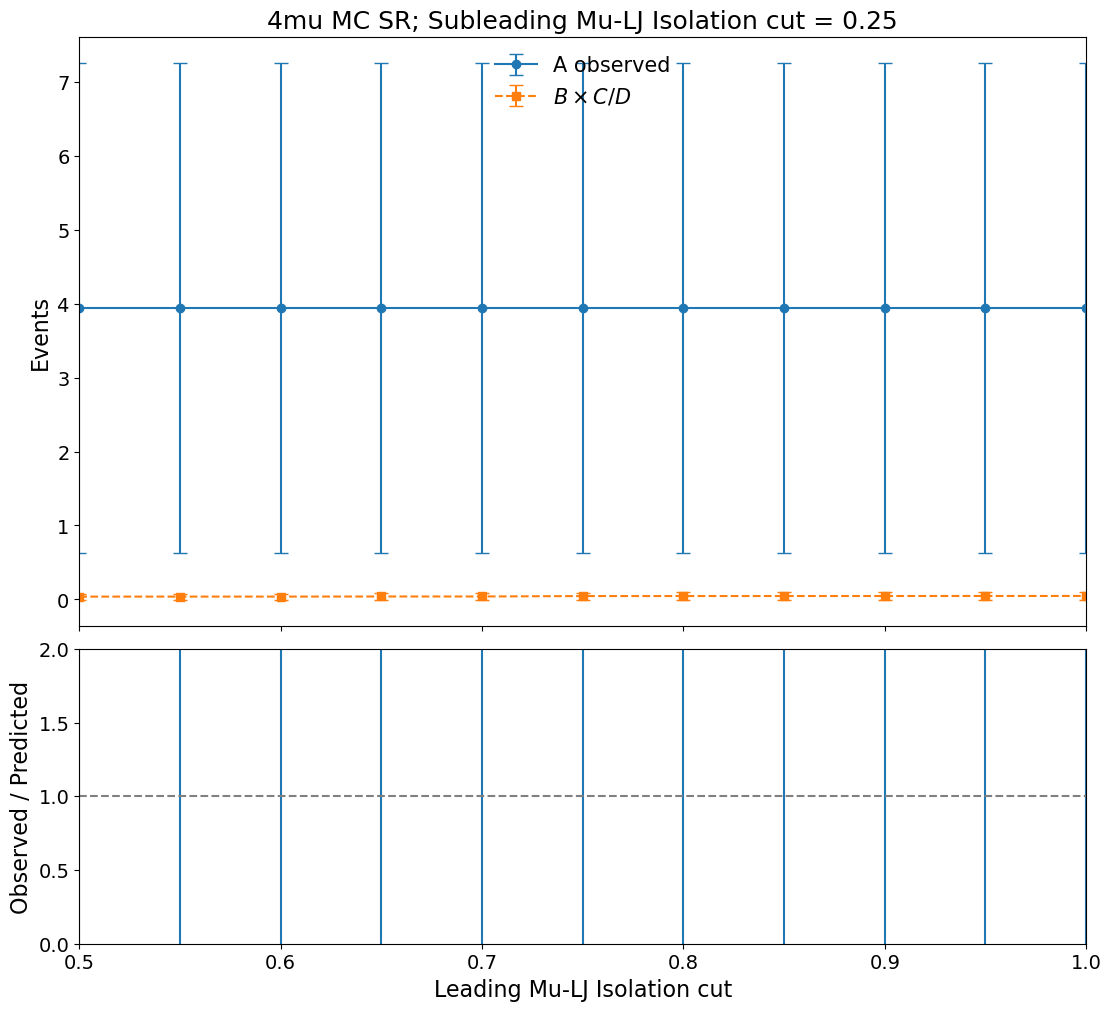

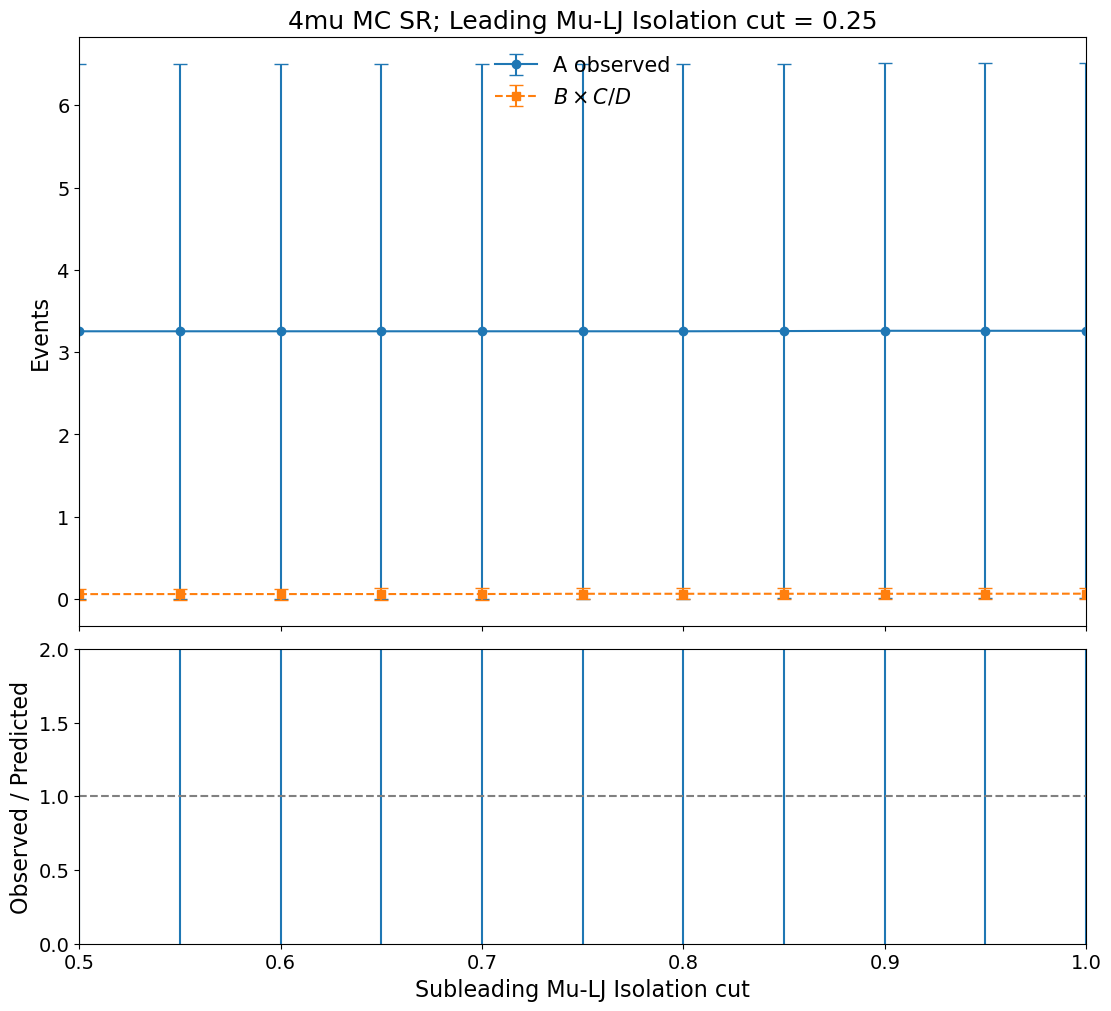

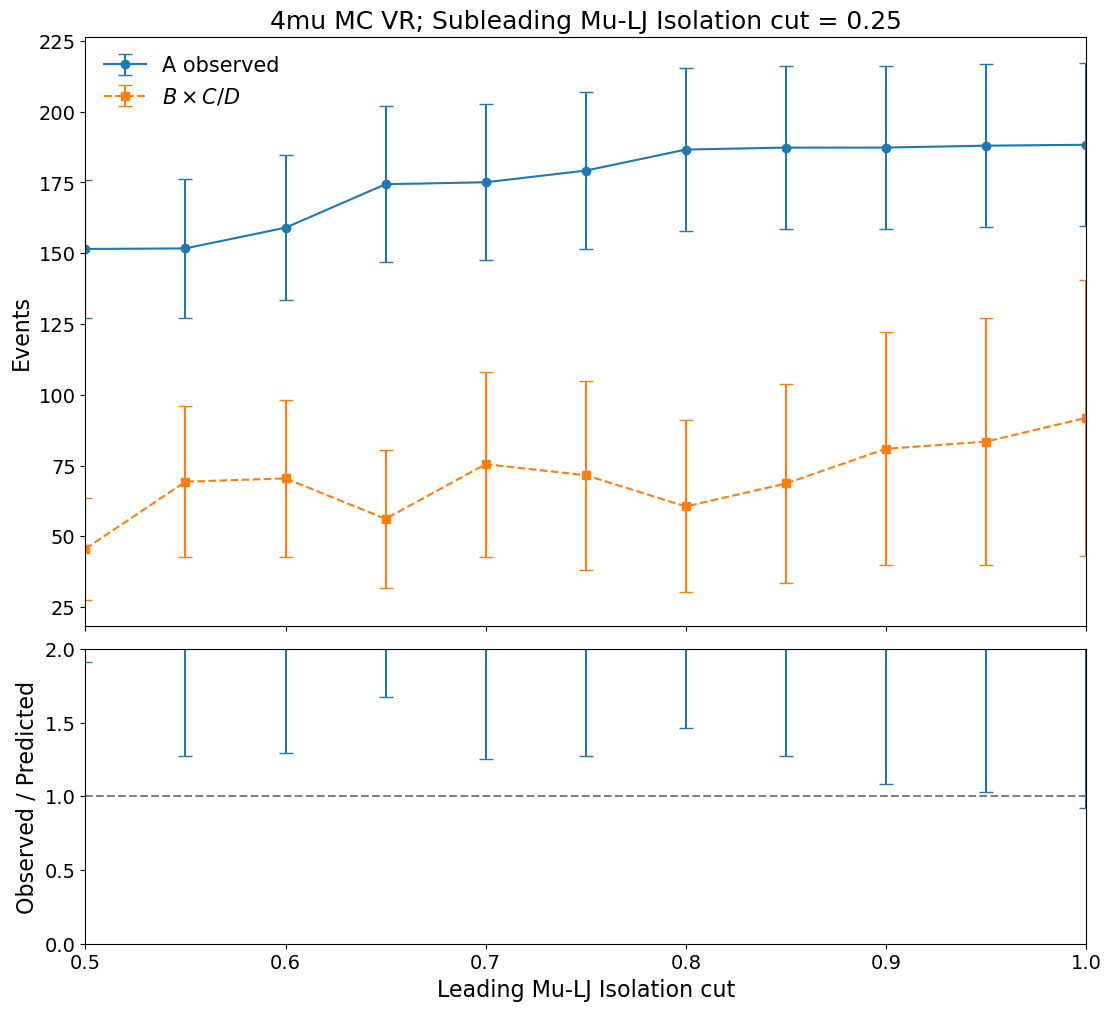

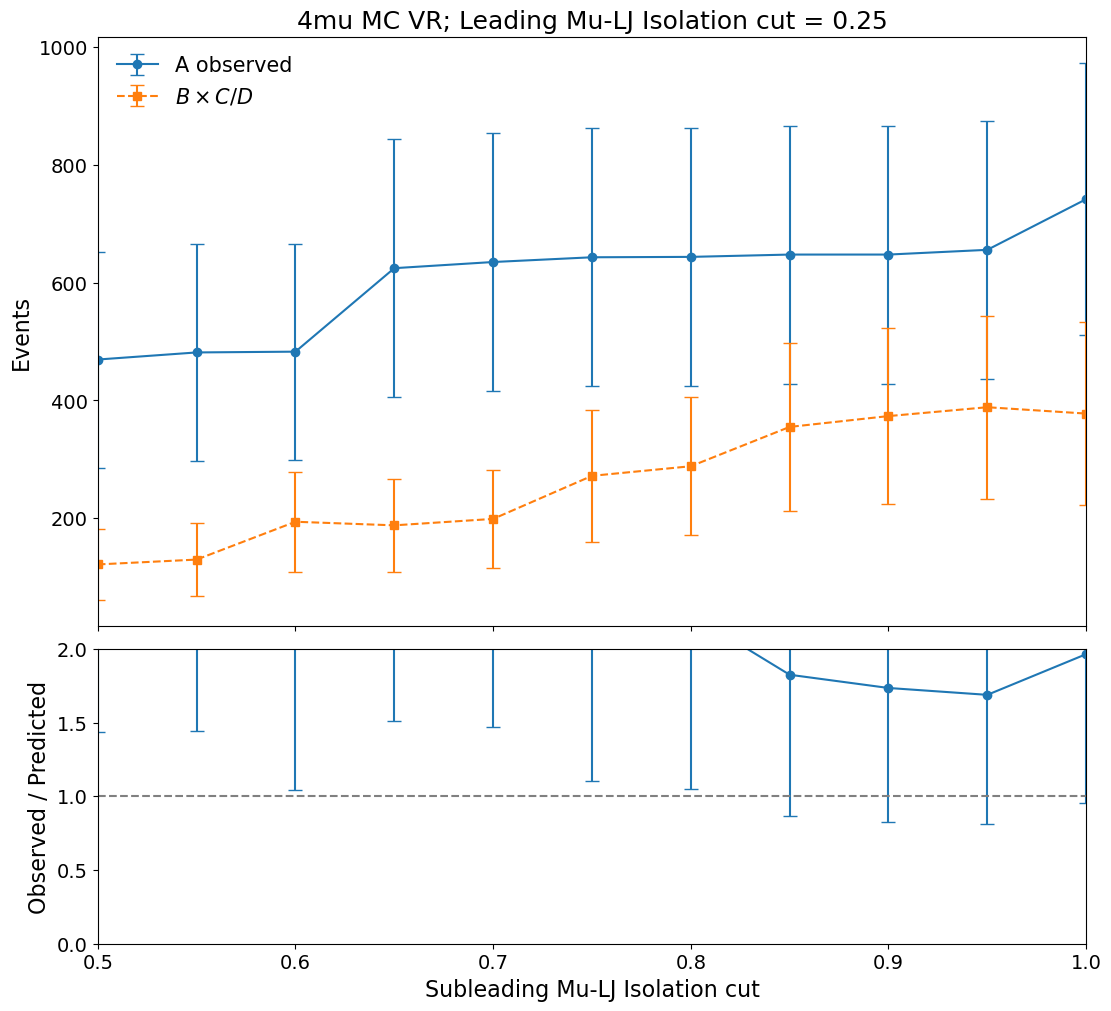

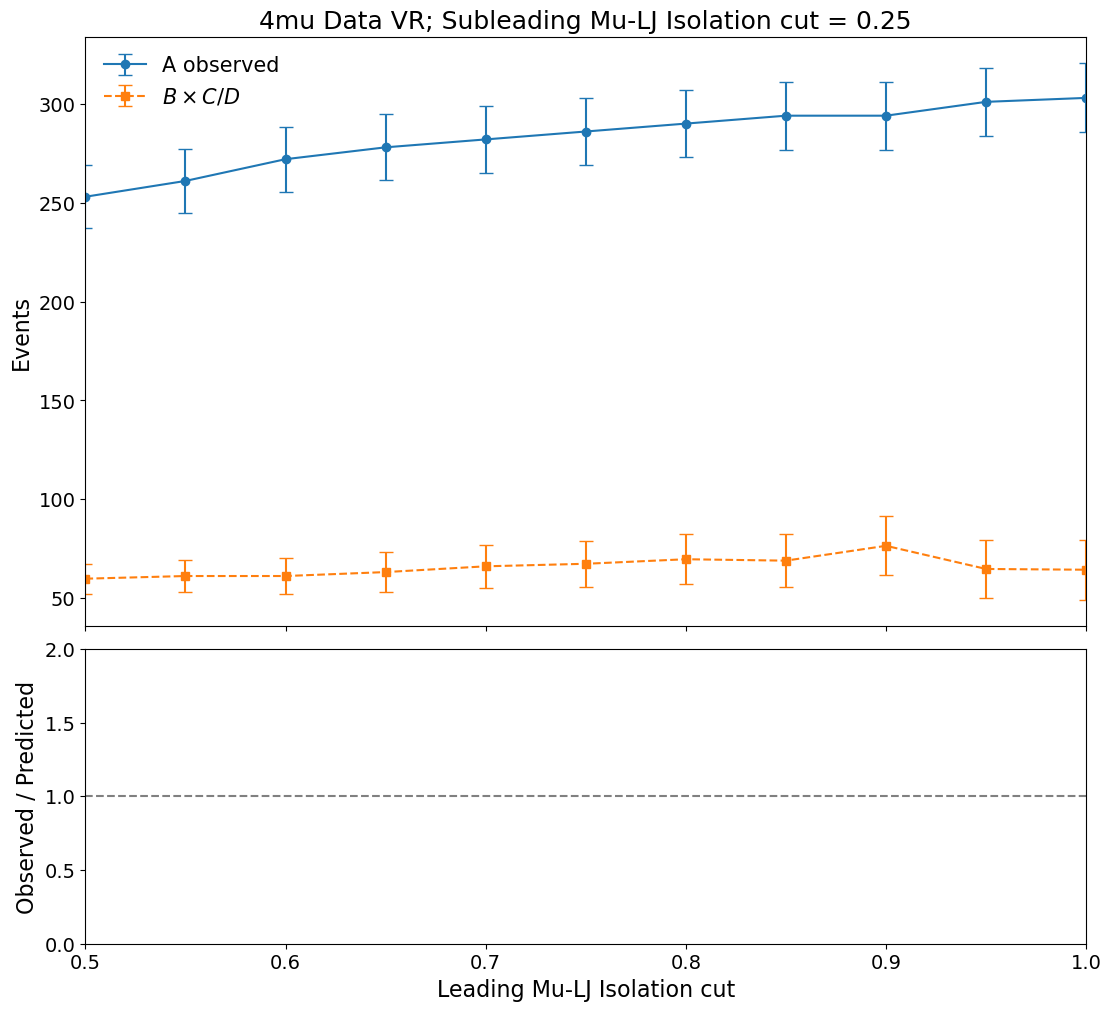

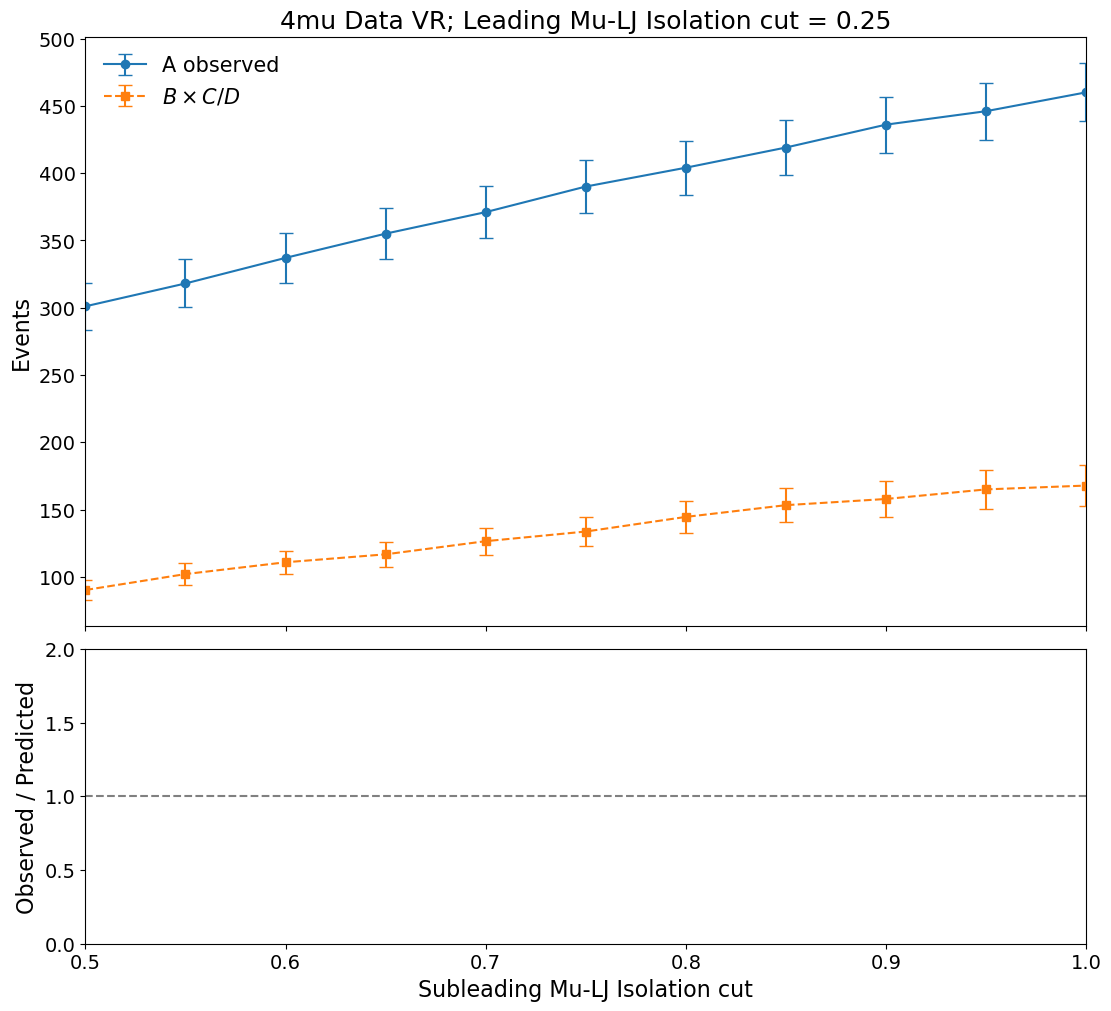

In [7]:
def scan_one_axis(h2d, scan_axis):
    rows = []
    for scan_cut in ONE_D_SCAN_VALUES:
        cuts = ((scan_cut, NOMINAL_CUTS[1]) if scan_axis == "x"
                else (NOMINAL_CUTS[0], scan_cut))
        rows.append(closure_row(h2d, cuts))
    return pd.DataFrame(rows)

def plot_one_axis_scan(frame, scan_axis, scan_label, fixed_label, title):
    fig, axes = plt.subplots(
        2, 1, figsize=(11, 10), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}, constrained_layout=True,
    )
    scan_coordinate = frame["xcut"] if scan_axis == "x" else frame["ycut"]
    axes[0].errorbar(
        scan_coordinate, frame.A_yield, yerr=frame.A_error,
        fmt="o-", capsize=5, label="A observed",
    )
    axes[0].errorbar(
        scan_coordinate, frame.A_pred, yerr=frame.A_pred_err,
        fmt="s--", capsize=5, label=r"$B \times C/D$",
    )
    axes[0].set(
        ylabel="Events",
        title=f"4mu {title}; {fixed_label} cut = 0.25",
    )
    axes[0].legend(frameon=False, fontsize=15)
    axes[1].errorbar(
        scan_coordinate, frame.observed_over_predicted,
        yerr=frame.observed_over_predicted_err, fmt="o-", capsize=5,
    )
    axes[1].axhline(1, color="gray", linestyle="--")
    axes[1].set(
        xlim=(0.50, 1.00), ylim=(0, 2),
        xlabel=f"{scan_label} cut", ylabel="Observed / Predicted",
    )
    for ax in axes:
        ax.tick_params(axis="both", labelsize=14)
        ax.xaxis.label.set_size(16); ax.yaxis.label.set_size(16)
        ax.title.set_size(18)
    return fig

one_axis_scans = {}
for selection, group, label in TARGETS:
    hist = group_hist(group, selection)
    for scan_axis, scan_label, fixed_label in [
        ("x", X_LABEL, Y_LABEL),
        ("y", Y_LABEL, X_LABEL),
    ]:
        frame = scan_one_axis(hist, scan_axis)
        one_axis_scans[(label, scan_axis)] = frame
        fig = plot_one_axis_scan(
            frame, scan_axis, scan_label, fixed_label, label,
        )
        plt.show(); plt.close(fig)

## 6. Two-dimensional isolation scans

The displayed uncertainties are statistical only.

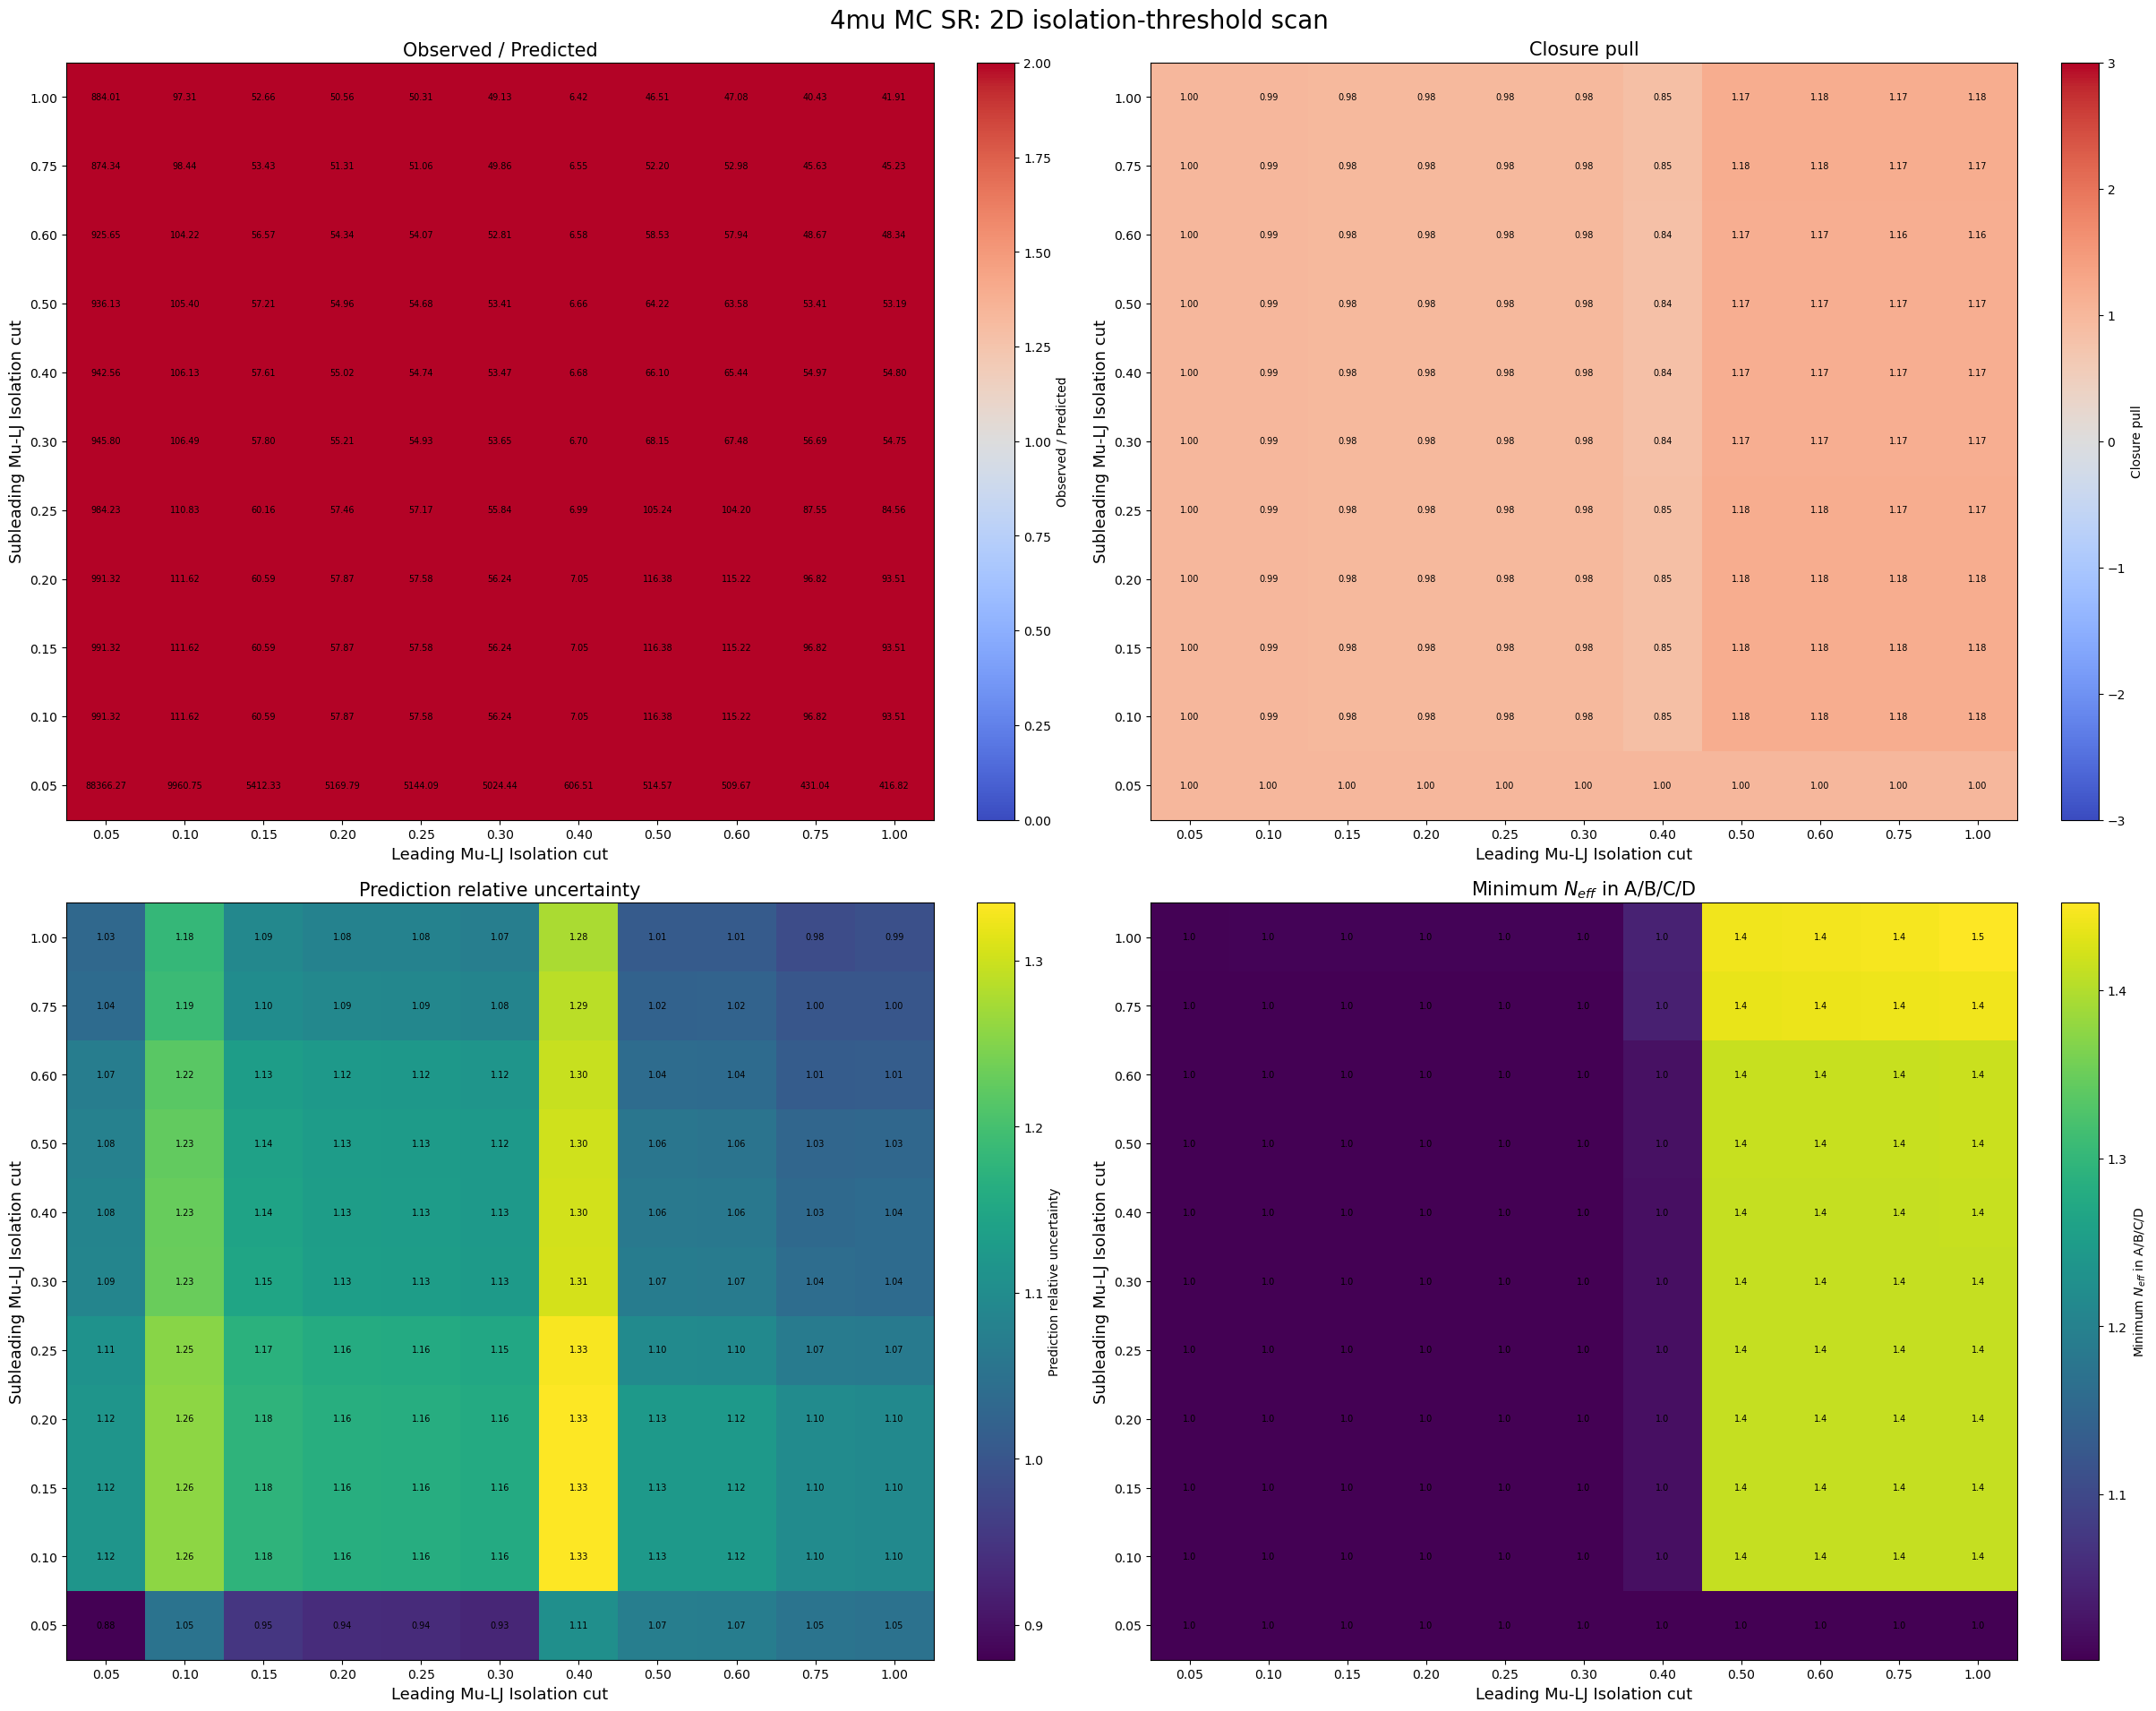

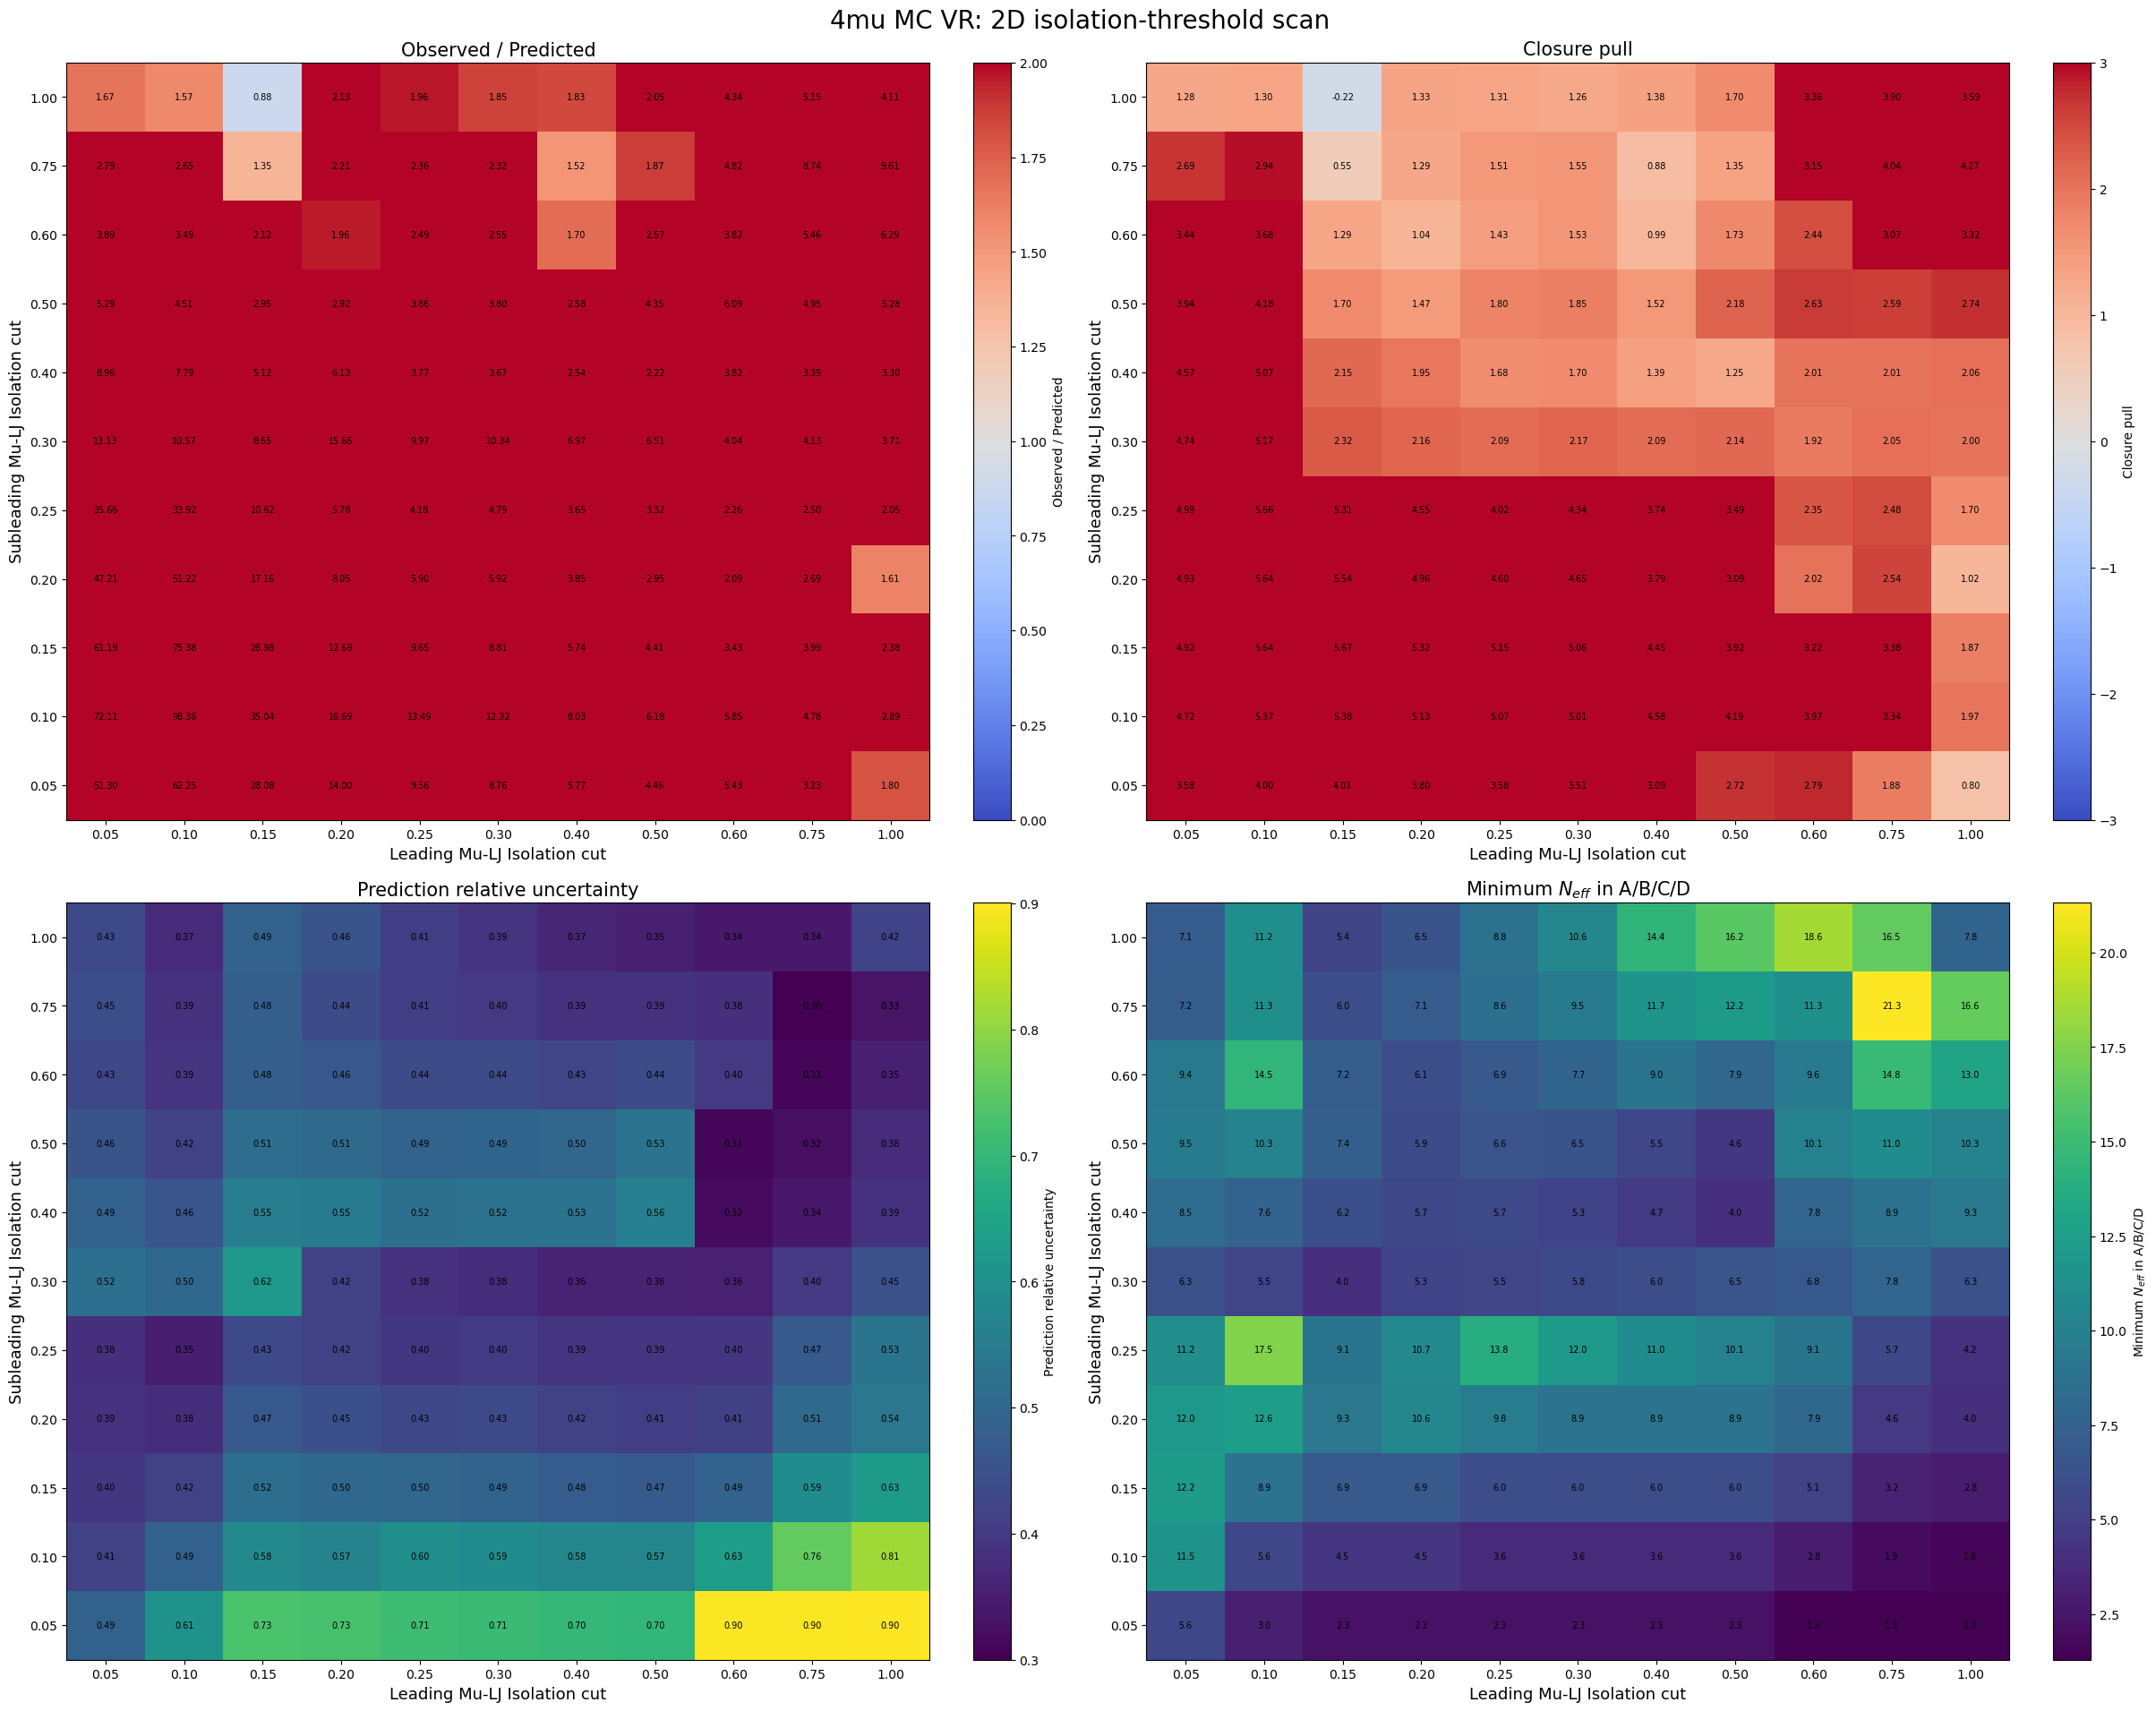

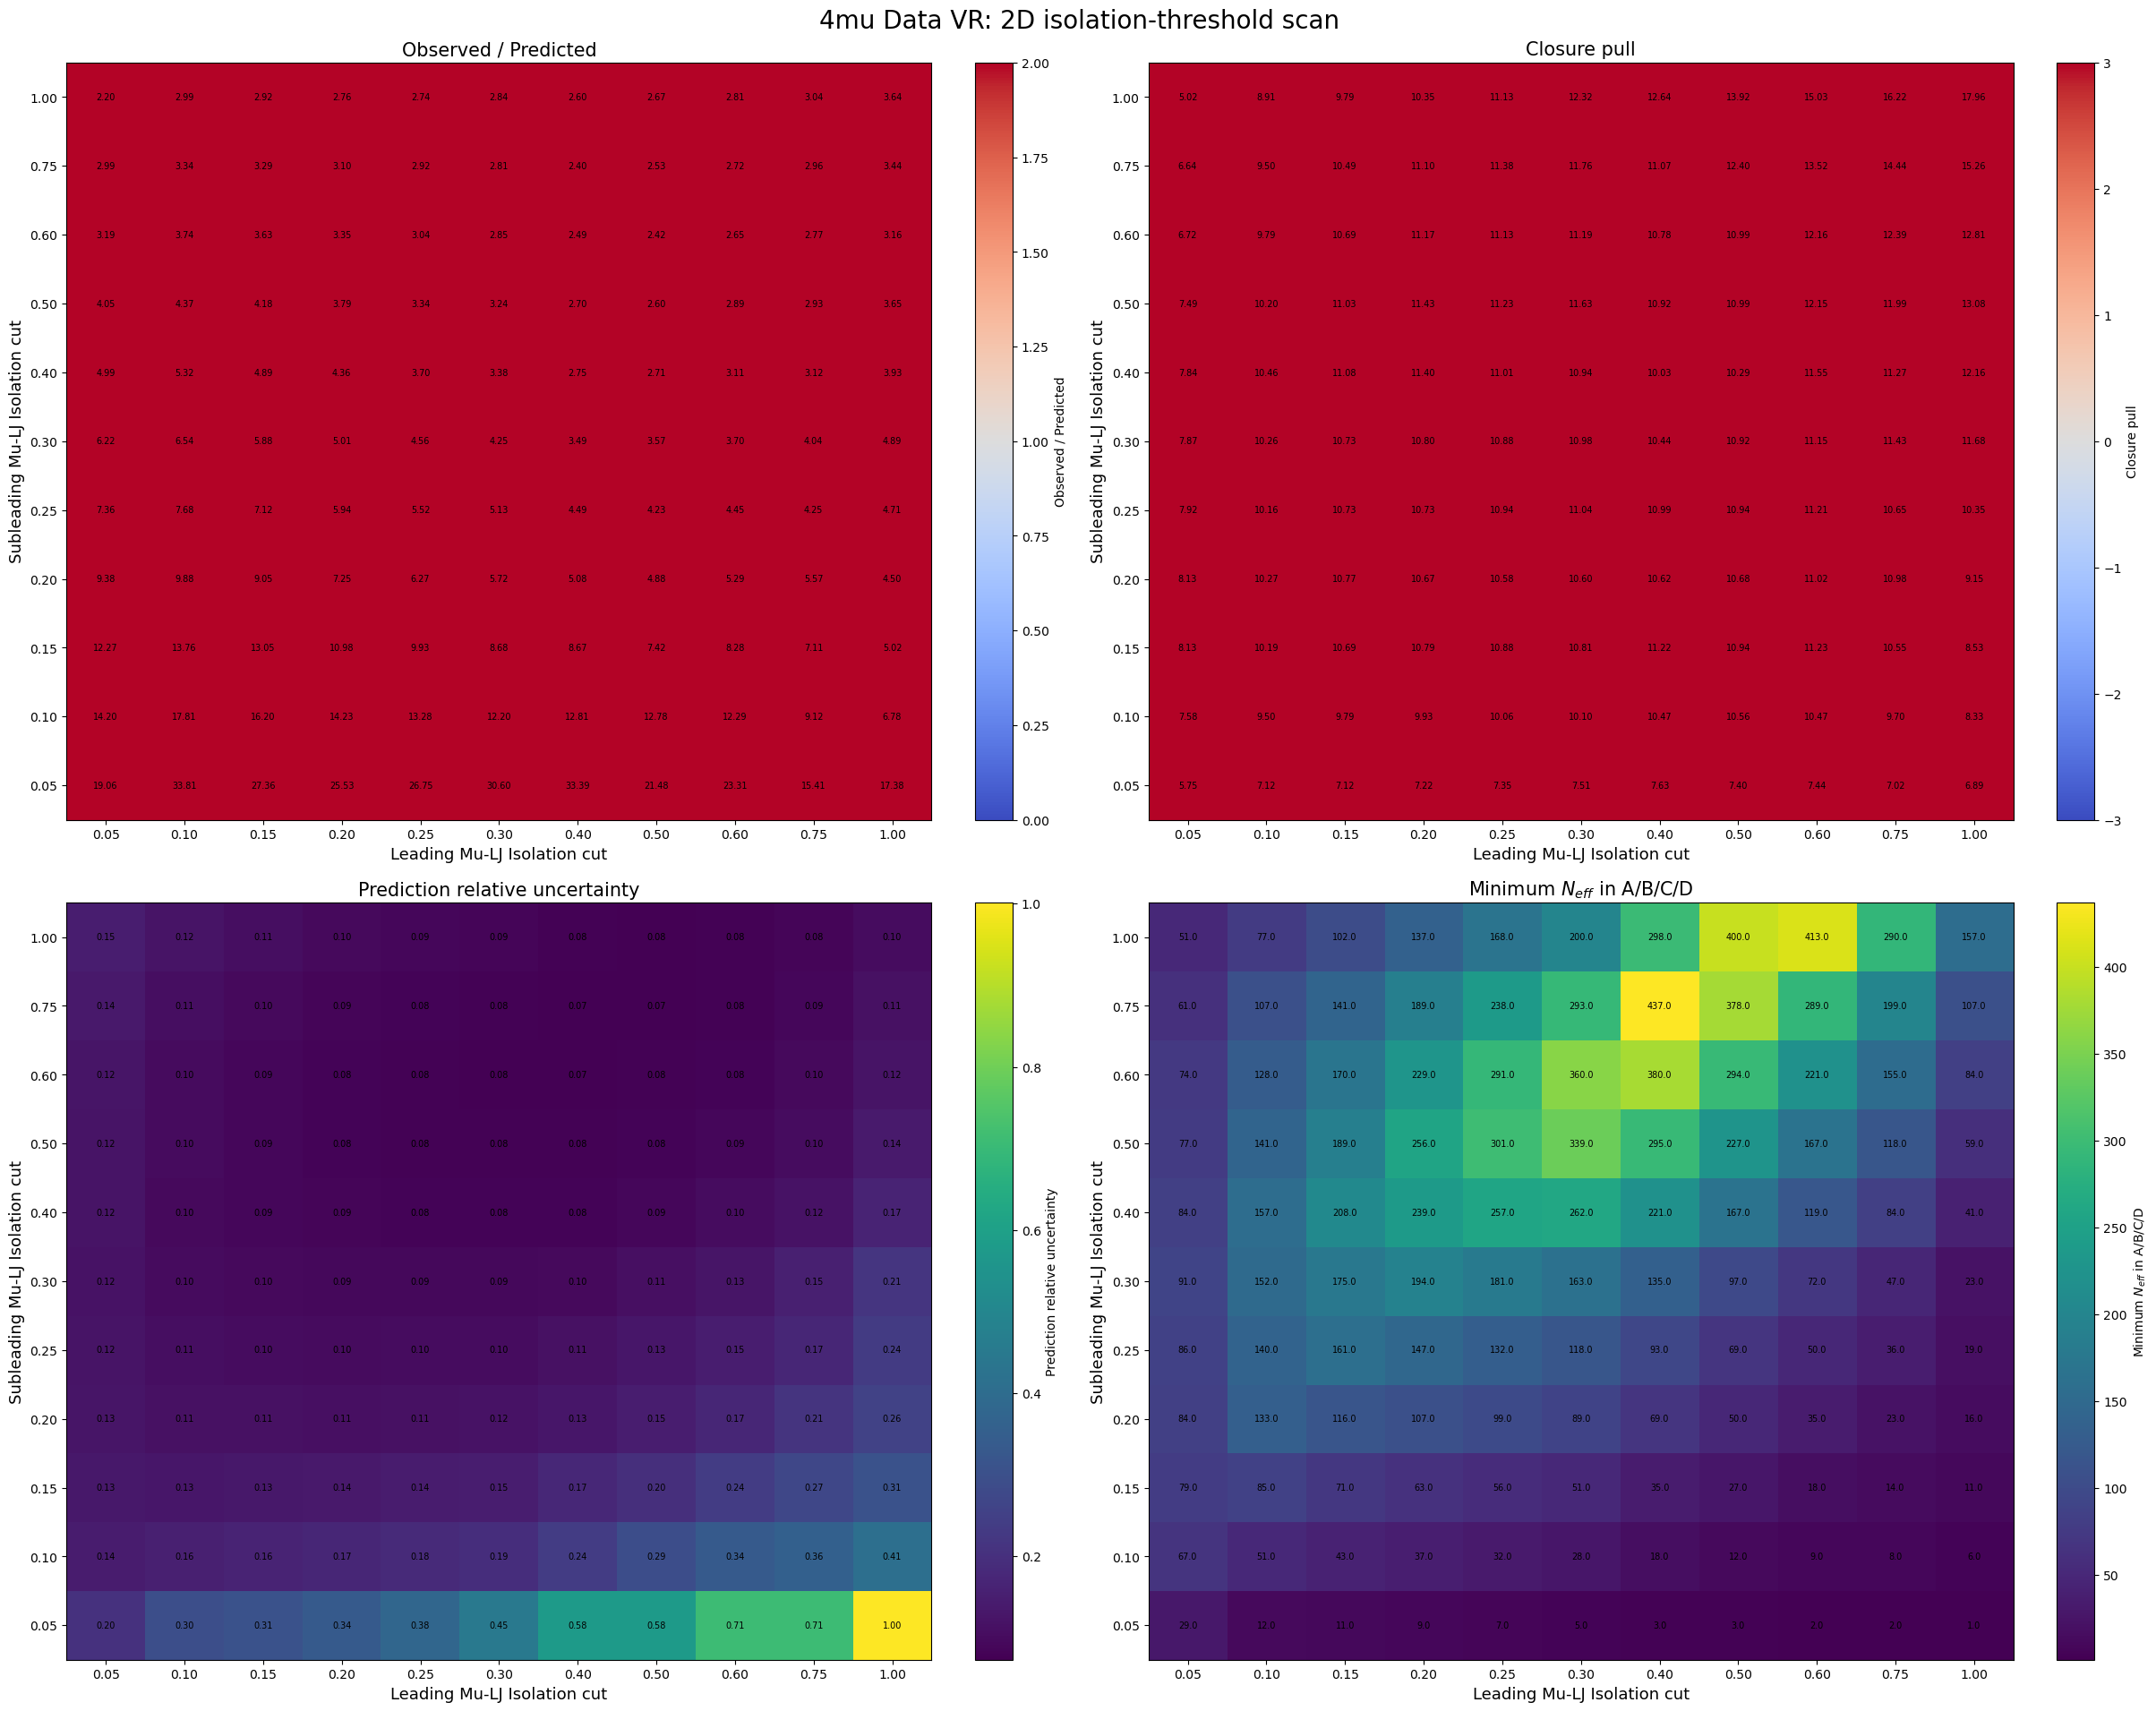

In [8]:
def scan_two_axes(h2d):
    return pd.DataFrame(
        closure_row(h2d, (xcut, ycut))
        for xcut in SCAN_VALUES for ycut in SCAN_VALUES
    )

def draw_heatmap(ax, frame, value, title, cmap="viridis", vmin=None, vmax=None,
                 number_format=".2f"):
    table = frame.pivot(index="ycut", columns="xcut", values=value)
    image = ax.imshow(table.values, origin="lower", aspect="auto",
                      cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(table.columns)), [f"{x:.2f}" for x in table.columns])
    ax.set_yticks(range(len(table.index)), [f"{y:.2f}" for y in table.index])
    ax.set(xlabel=f"{X_LABEL} cut", ylabel=f"{Y_LABEL} cut", title=title)
    ax.tick_params(axis="both", labelsize=10)
    ax.xaxis.label.set_size(13); ax.yaxis.label.set_size(13); ax.title.set_size(15)
    for row_index, ycut in enumerate(table.index):
        for column_index, xcut in enumerate(table.columns):
            value_here = table.loc[ycut, xcut]
            label = format(value_here, number_format) if np.isfinite(value_here) else "nan"
            ax.text(column_index, row_index, label, ha="center", va="center", fontsize=7)
    plt.colorbar(image, ax=ax, label=title)

two_axis_scans = {}
for selection, group, label in TARGETS:
    hist = group_hist(group, selection)
    assert hist is not None, f"Missing histogram for {label}"
    frame = scan_two_axes(hist)
    two_axis_scans[label] = frame

    fig, axes = plt.subplots(2, 2, figsize=(24, 19), constrained_layout=True)
    draw_heatmap(
        axes[0, 0], frame, "observed_over_predicted", "Observed / Predicted",
        cmap="coolwarm", vmin=0, vmax=2,
    )
    draw_heatmap(
        axes[0, 1], frame, "pull", "Closure pull",
        cmap="coolwarm", vmin=-3, vmax=3,
    )
    draw_heatmap(
        axes[1, 0], frame, "relative_pred_err", "Prediction relative uncertainty",
        cmap="viridis",
    )
    draw_heatmap(
        axes[1, 1], frame, "min_neff", r"Minimum $N_{eff}$ in A/B/C/D",
        cmap="viridis", number_format=".1f",
    )
    fig.suptitle(f"4mu {label}: 2D isolation-threshold scan", fontsize=20)
    plt.show(); plt.close(fig)

## 7. Numerical scan tables

In [9]:
scan_columns = [
    "xcut", "ycut", "A_yield", "A_error", "A_pred", "A_pred_err",
    "observed_over_predicted", "observed_over_predicted_err", "pull",
    "relative_pred_err", "min_neff",
]
for label, frame in two_axis_scans.items():
    print(label)
    display(frame[scan_columns])

MC SR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,observed_over_predicted,observed_over_predicted_err,pull,relative_pred_err,min_neff
0,0.05,0.05,3.250611,3.248041,0.000037,0.000032,88366.265437,117606.286921,1.000780,0.879127,1.001583
1,0.05,0.10,3.250611,3.248041,0.003279,0.003663,991.320953,1485.693520,0.999781,1.116998,1.001583
2,0.05,0.15,3.250611,3.248041,0.003279,0.003663,991.320953,1485.693520,0.999781,1.116998,1.001583
3,0.05,0.20,3.250611,3.248041,0.003279,0.003663,991.320953,1485.693520,0.999781,1.116998,1.001583
4,0.05,0.25,3.250611,3.248041,0.003303,0.003673,984.232524,1471.461447,0.999774,1.112074,1.001583
...,...,...,...,...,...,...,...,...,...,...,...
116,1.00,0.40,3.941083,3.314294,0.071922,0.074691,54.796877,73.225179,1.167120,1.038503,1.413999
117,1.00,0.50,3.943654,3.314295,0.074144,0.076501,53.188932,70.781019,1.167210,1.031792,1.415843
118,1.00,0.60,3.943654,3.314295,0.081575,0.082629,48.343879,63.628740,1.164917,1.012921,1.415843
119,1.00,0.75,3.980541,3.314427,0.088008,0.088095,45.229206,58.889832,1.174007,1.000983,1.442339


MC VR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,observed_over_predicted,observed_over_predicted_err,pull,relative_pred_err,min_neff
0,0.05,0.05,42.824774,11.716103,0.834860,0.405978,51.295732,28.620901,3.581799,0.486282,5.615970
1,0.05,0.10,73.050940,15.245082,1.013112,0.420394,72.105523,33.491320,4.723520,0.414954,11.467956
2,0.05,0.15,79.753730,15.923403,1.303421,0.518818,61.187994,27.247640,4.924117,0.398043,12.171580
3,0.05,0.20,80.412457,15.937023,1.703383,0.656755,47.207503,20.465181,4.934568,0.385559,11.962899
4,0.05,0.25,83.663067,16.264638,2.346175,0.893287,35.659351,15.244453,4.992089,0.380742,11.176796
...,...,...,...,...,...,...,...,...,...,...,...
116,1.00,0.40,582.009755,185.248208,176.100802,68.434478,3.304981,1.660161,2.055395,0.388610,9.349393
117,1.00,0.50,872.024767,250.273935,165.159753,62.147302,5.279887,2.498687,2.741119,0.376286,10.271369
118,1.00,0.60,1095.924368,270.363786,174.212580,61.317120,6.290730,2.703854,3.324721,0.351967,12.971117
119,1.00,0.75,1615.014748,334.592462,168.062282,55.563940,9.609620,3.749333,4.266098,0.330615,16.565299


Data VR


,xcut,ycut,A_yield,A_error,A_pred,A_pred_err,observed_over_predicted,observed_over_predicted_err,pull,relative_pred_err,min_neff
0,0.05,0.05,37.0,6.082763,1.941150,0.396125,19.060866,4.994908,5.751457,0.204067,29.0
1,0.05,0.10,67.0,8.185353,4.718303,0.675432,14.200020,2.672385,7.583147,0.143151,67.0
2,0.05,0.15,79.0,8.888194,6.439116,0.854935,12.268765,2.135141,8.126232,0.132772,79.0
3,0.05,0.20,84.0,9.165151,8.955137,1.124960,9.380090,1.560752,8.127074,0.125622,84.0
4,0.05,0.25,86.0,9.273618,11.688955,1.418780,7.357373,1.194537,7.921002,0.121378,86.0
...,...,...,...,...,...,...,...,...,...,...,...
116,1.00,0.40,502.0,22.405357,127.802603,21.099175,3.927933,0.671750,12.158657,0.165092,41.0
117,1.00,0.50,634.0,25.179357,173.803612,24.562806,3.647795,0.535494,13.082784,0.141325,59.0
118,1.00,0.60,753.0,27.440845,238.334928,29.326119,3.159419,0.405445,12.814588,0.123046,84.0
119,1.00,0.75,935.0,30.577770,271.969620,30.858014,3.437884,0.405947,15.262389,0.113461,107.0
